In [89]:
import warnings, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, pointbiserialr
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
plt.rcParams['font.family'] = 'NanumGothic'   # 한글 렌더링

In [90]:
train_df = pd.read_csv('./data/air/train.csv')
test_df = pd.read_csv('./data/air/test.csv')
# print(f'행 {df.shape[0]:,} / 열 {df.shape[1]}')
# print(f'중복 행: {df.duplicated().sum()}')

# miss = pd.DataFrame({
#     '결측수': df.isnull().sum(),
#     '결측비율(%)': (df.isnull().mean() * 100).round(3)
# })
# miss[miss['결측수'] > 0]

In [132]:
RS=10

In [91]:
train_df.columns = [c.strip().replace(' ', '_').replace('/', '_') for c in train_df.columns]
print(list(train_df.columns))
test_df.columns = [c.strip().replace(' ', '_').replace('/', '_') for c in test_df.columns]
print(list(test_df.columns))

['Unnamed:_0', 'id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'satisfaction']
['Unnamed:_0', 'id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'satisfaction']


In [92]:
ID_COLS = ['Unnamed:_0', 'id']
before = train_df.shape[1]
train_df = train_df.drop(columns=[c for c in ID_COLS if c in train_df.columns])
print(f'식별자 제거: {before} → {train_df.shape[1]}개 컬럼')
before = test_df.shape[1]
test_df = test_df.drop(columns=[c for c in ID_COLS if c in test_df.columns])
print(f'식별자 제거: {before} → {test_df.shape[1]}개 컬럼')

식별자 제거: 25 → 23개 컬럼
식별자 제거: 25 → 23개 컬럼


In [93]:
med = train_df['Arrival_Delay_in_Minutes'].median()
print(f'train 중앙값 {med}   (참고: train 평균 {train_df["Arrival_Delay_in_Minutes"].mean():.2f})')

for d in (train_df, test_df):
    d['Arrival_Delay_in_Minutes'] = d['Arrival_Delay_in_Minutes'].fillna(med)

print('결측치 잔여:', train_df.isnull().sum().sum(), test_df.isnull().sum().sum())

train 중앙값 0.0   (참고: train 평균 15.18)
결측치 잔여: 0 0


In [94]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  str    
 1   Customer_Type                      103904 non-null  str    
 2   Age                                103904 non-null  int64  
 3   Type_of_Travel                     103904 non-null  str    
 4   Class                              103904 non-null  str    
 5   Flight_Distance                    103904 non-null  int64  
 6   Inflight_wifi_service              103904 non-null  int64  
 7   Departure_Arrival_time_convenient  103904 non-null  int64  
 8   Ease_of_Online_booking             103904 non-null  int64  
 9   Gate_location                      103904 non-null  int64  
 10  Food_and_drink                     103904 non-null  int64  
 11  Online_boarding                    103904 non-null

In [95]:
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
num_cols = train_df.select_dtypes(include='number').columns.tolist()

rating_cols = [c for c in num_cols if train_df[c].between(0, 5).all()]
other_num   = [c for c in num_cols if c not in rating_cols]

print(f'범주형 {len(cat_cols)}개 : {cat_cols}')
print(f'서비스 평점 {len(rating_cols)}개')
print(f'기타 수치형 {len(other_num)}개 : {other_num}')

card = pd.DataFrame({
    '고유값수': train_df[cat_cols + rating_cols].nunique(),
    '최빈값': train_df[cat_cols + rating_cols].mode().iloc[0]
})
display(card)

범주형 5개 : ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class', 'satisfaction']
서비스 평점 14개
기타 수치형 4개 : ['Age', 'Flight_Distance', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']


C:\Users\KDT11\AppData\Local\Temp\ipykernel_18796\3018374405.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include='object').columns.tolist()


,고유값수,최빈값
Gender,2,Female
Customer_Type,2,Loyal Customer
Type_of_Travel,2,Business travel
Class,3,Business
satisfaction,2,neutral or dissatisfied
Inflight_wifi_service,6,3
Departure_Arrival_time_convenient,6,4
Ease_of_Online_booking,6,3
Gate_location,6,3
Food_and_drink,6,4


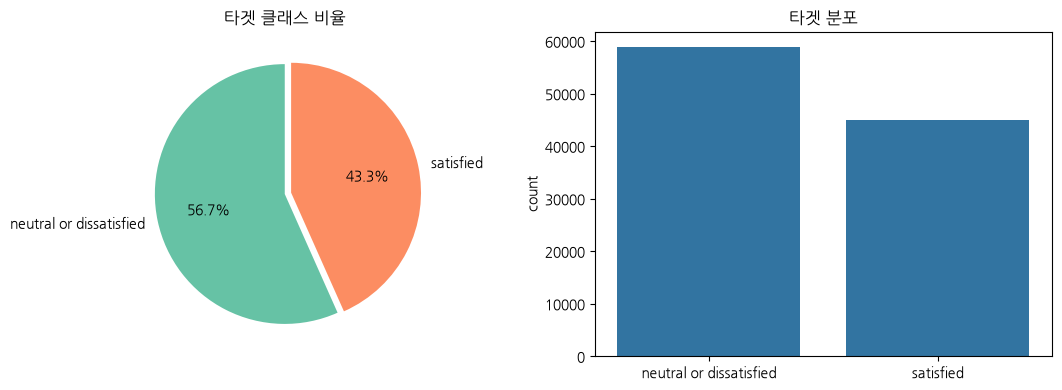

불균형비 1.31 : 1
→ 리샘플링 불필요


In [96]:
TARGET = 'satisfaction'
vc = train_df[TARGET].value_counts()
ratio = vc / vc.sum()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90,
          colors=sns.color_palette('Set2'), explode=[0, 0.05])
ax[0].set_title('타겟 클래스 비율')
sns.countplot(data=train_df, x=TARGET, ax=ax[1])
ax[1].set_title('타겟 분포')
ax[1].set_xlabel('')
plt.tight_layout(); plt.show()

imb = ratio.max() / ratio.min()
print(f'불균형비 {imb:.2f} : 1')
print('→ 리샘플링 불필요' if imb < 1.5 else '→ 리샘플링 검토 필요')

In [97]:
sk = train_df[other_num].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
display(sk.to_frame('왜도').style.format('{:.3f}'))

high_skew = sk[sk.abs() > 0.5].index.tolist()
print(f'왜도 0.5 초과: {high_skew}')

,왜도
Departure_Delay_in_Minutes,6.734
Arrival_Delay_in_Minutes,6.605
Flight_Distance,1.109
Age,-0.005


왜도 0.5 초과: ['Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'Flight_Distance']


상관 0.5 초과 쌍


,,상관계수
Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,0.960
Inflight_wifi_service,Ease_of_Online_booking,0.716
Inflight_entertainment,Cleanliness,0.692
Seat_comfort,Cleanliness,0.679
Food_and_drink,Cleanliness,0.658
Baggage_handling,Inflight_service,0.629
Food_and_drink,Inflight_entertainment,0.623
Seat_comfort,Inflight_entertainment,0.611
Food_and_drink,Seat_comfort,0.575
On-board_service,Inflight_service,0.551


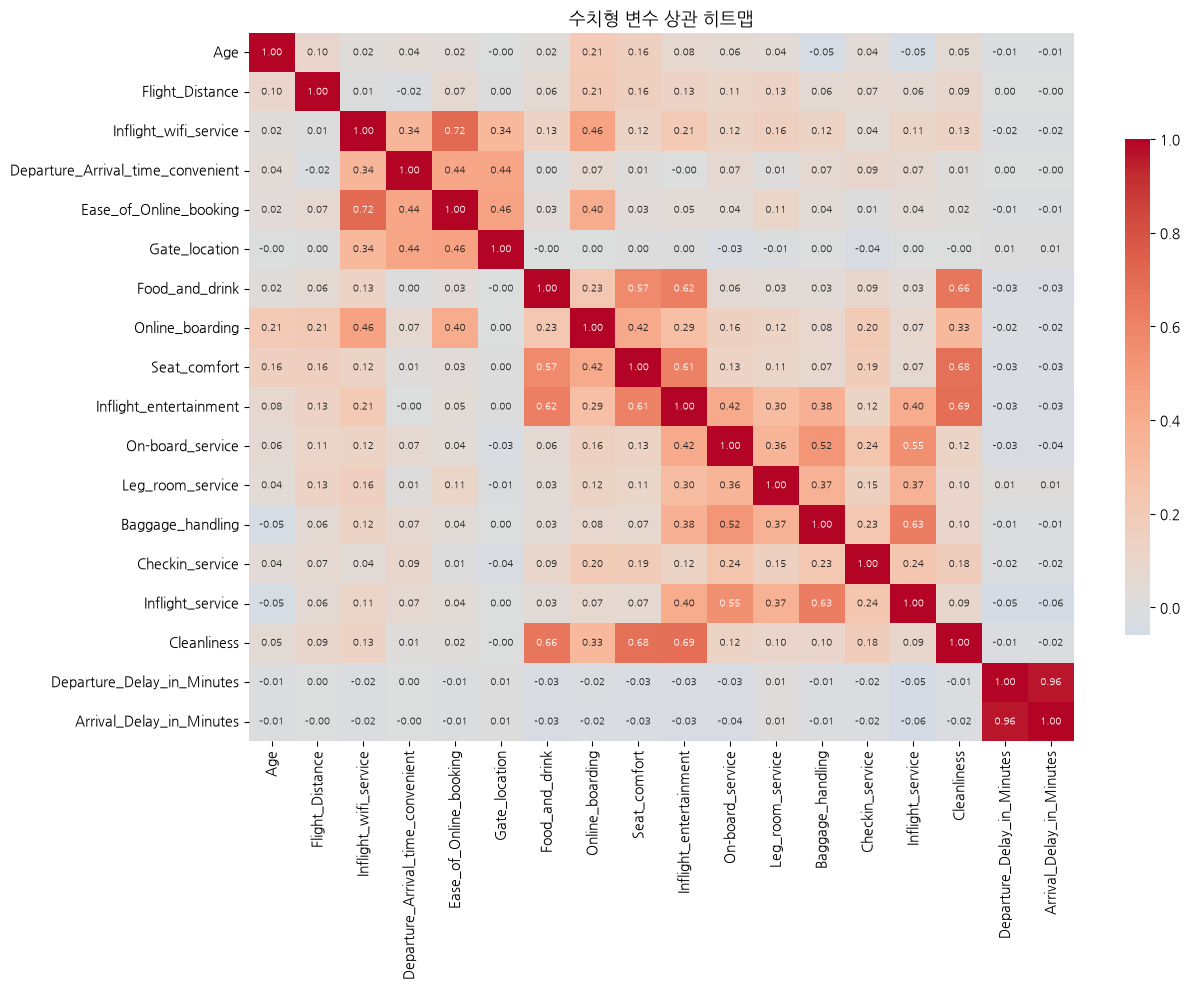

In [98]:
corr = train_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = corr.where(mask).stack().sort_values(ascending=False)

print('상관 0.5 초과 쌍')
display(pairs[pairs.abs() > 0.5].to_frame('상관계수').style.format('{:.3f}'))

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
plt.title('수치형 변수 상관 히트맵', fontsize=13)
plt.tight_layout(); plt.show()

타겟과의 point-biserial 상관 (상위/하위)


,r
Online_boarding,+0.5036
Inflight_entertainment,+0.3981
Seat_comfort,+0.3495
On-board_service,+0.3224
Leg_room_service,+0.3131
Cleanliness,+0.3052
Flight_Distance,+0.2988
Inflight_wifi_service,+0.2842
Baggage_handling,+0.2477
Inflight_service,+0.2447



도착 지연 구간별 만족률


,만족률,건수
Arrival_Delay_in_Minutes,,
0분,0.4725,"58,469"
1-5분,0.4811,"9,792"
6-15분,0.3575,"12,008"
16-30분,0.3527,"8,973"
31-60분,0.3564,"7,335"
61-120분,0.3524,"4,710"
120분+,0.3657,"2,617"


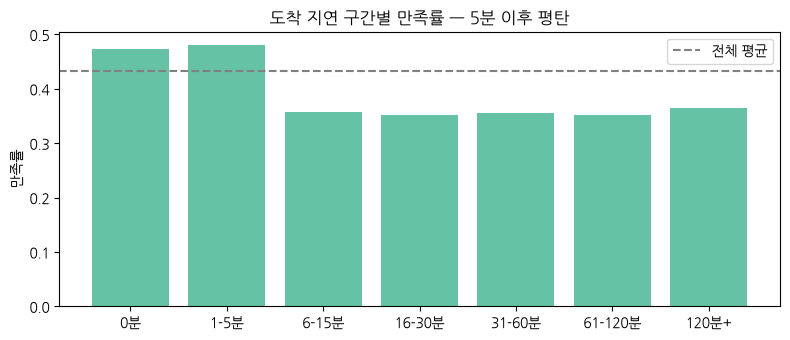

In [99]:
y_tr_bin = (train_df[TARGET] == 'satisfied').astype(int)

print('타겟과의 point-biserial 상관 (상위/하위)')
rs = {}
for c in num_cols:
    r, p = pointbiserialr(y_tr_bin, train_df[c])
    rs[c] = r
rs = pd.Series(rs).sort_values(key=abs, ascending=False)
display(rs.to_frame('r').style.format('{:+.4f}'))

bins = [-1, 0, 5, 15, 30, 60, 120, np.inf]
lbl  = ['0분', '1-5분', '6-15분', '16-30분', '31-60분', '61-120분', '120분+']
g = pd.cut(train_df['Arrival_Delay_in_Minutes'], bins=bins, labels=lbl)
tbl = pd.DataFrame({
    '만족률': y_tr_bin.groupby(g, observed=False).mean(),
    '건수': y_tr_bin.groupby(g, observed=False).size()
})
print('\n도착 지연 구간별 만족률')
display(tbl.style.format({'만족률': '{:.4f}', '건수': '{:,}'}))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(tbl.index, tbl['만족률'], color=sns.color_palette('Set2')[0])
ax.axhline(y_tr_bin.mean(), ls='--', c='gray', label='전체 평균')
ax.set_ylabel('만족률'); ax.set_title('도착 지연 구간별 만족률 — 5분 이후 평탄')
ax.legend(); plt.tight_layout(); plt.show()

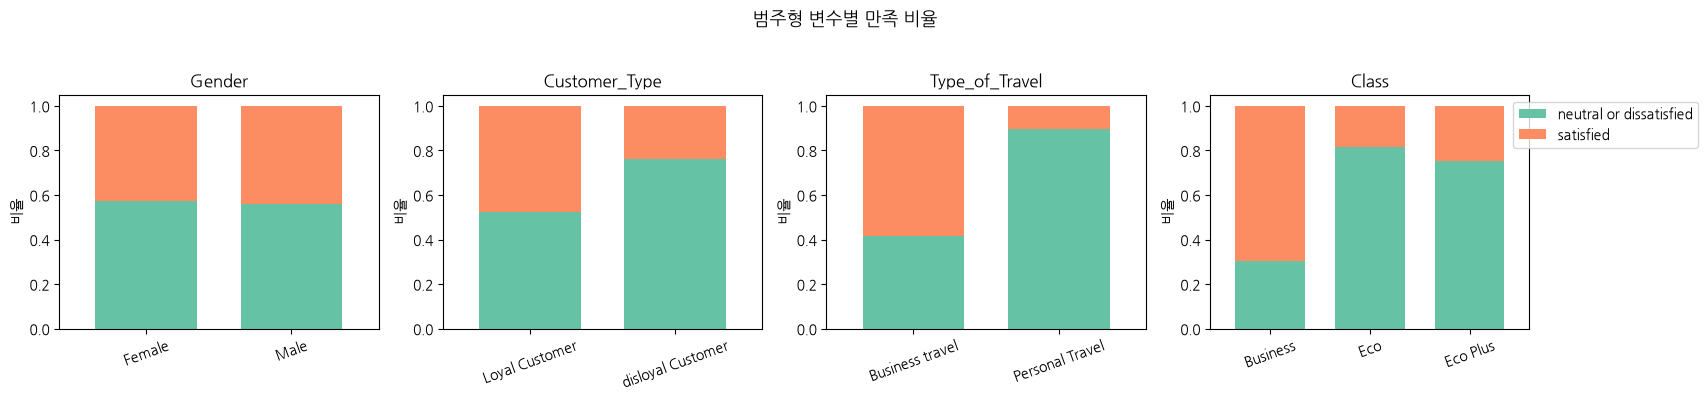

In [100]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, col in zip(axes, ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class']):
    ct = pd.crosstab(train_df[col], train_df[TARGET], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, legend=False, width=0.7,
            color=sns.color_palette('Set2')[:2])
    ax.set_title(col); ax.set_xlabel(''); ax.set_ylabel('비율')
    ax.tick_params(axis='x', rotation=20)
axes[-1].legend(title='', loc='upper right', bbox_to_anchor=(1.55, 1))
plt.suptitle('범주형 변수별 만족 비율', y=1.04, fontsize=13)
plt.tight_layout(); plt.show()

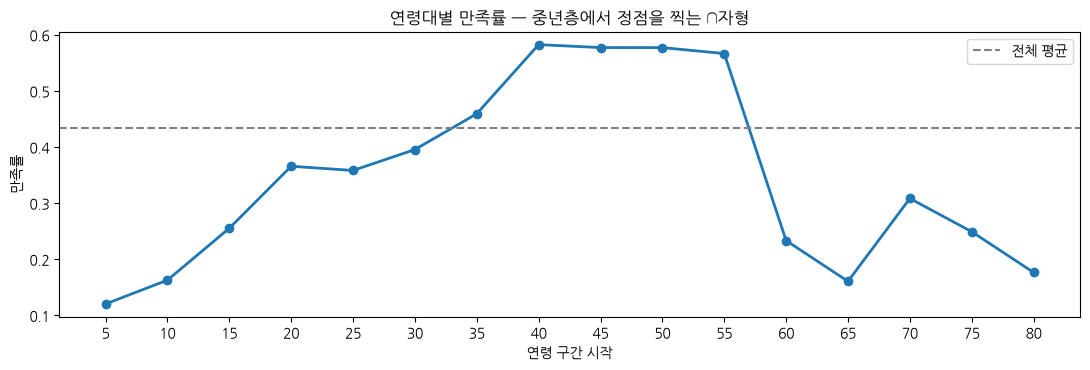

Age의 선형 상관계수: +0.1372  ← ∩자형이라 낮게 측정됨


In [101]:
# 연령 — 선형 상관으로는 잡히지 않는 ∩자형 패턴
age_bin = pd.cut(train_df['Age'], bins=range(0, 90, 5))
age_rate = y_tr_bin.groupby(age_bin, observed=False).mean()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot([str(i.left) for i in age_rate.index], age_rate.values, marker='o', lw=2)
ax.axhline(y_tr_bin.mean(), ls='--', c='gray', label='전체 평균')
ax.set_xlabel('연령 구간 시작'); ax.set_ylabel('만족률')
ax.set_title('연령대별 만족률 — 중년층에서 정점을 찍는 ∩자형')
ax.legend(); plt.tight_layout(); plt.show()

r_age, _ = pointbiserialr(y_tr_bin, train_df['Age'])
print(f'Age의 선형 상관계수: {r_age:+.4f}  ← ∩자형이라 낮게 측정됨')

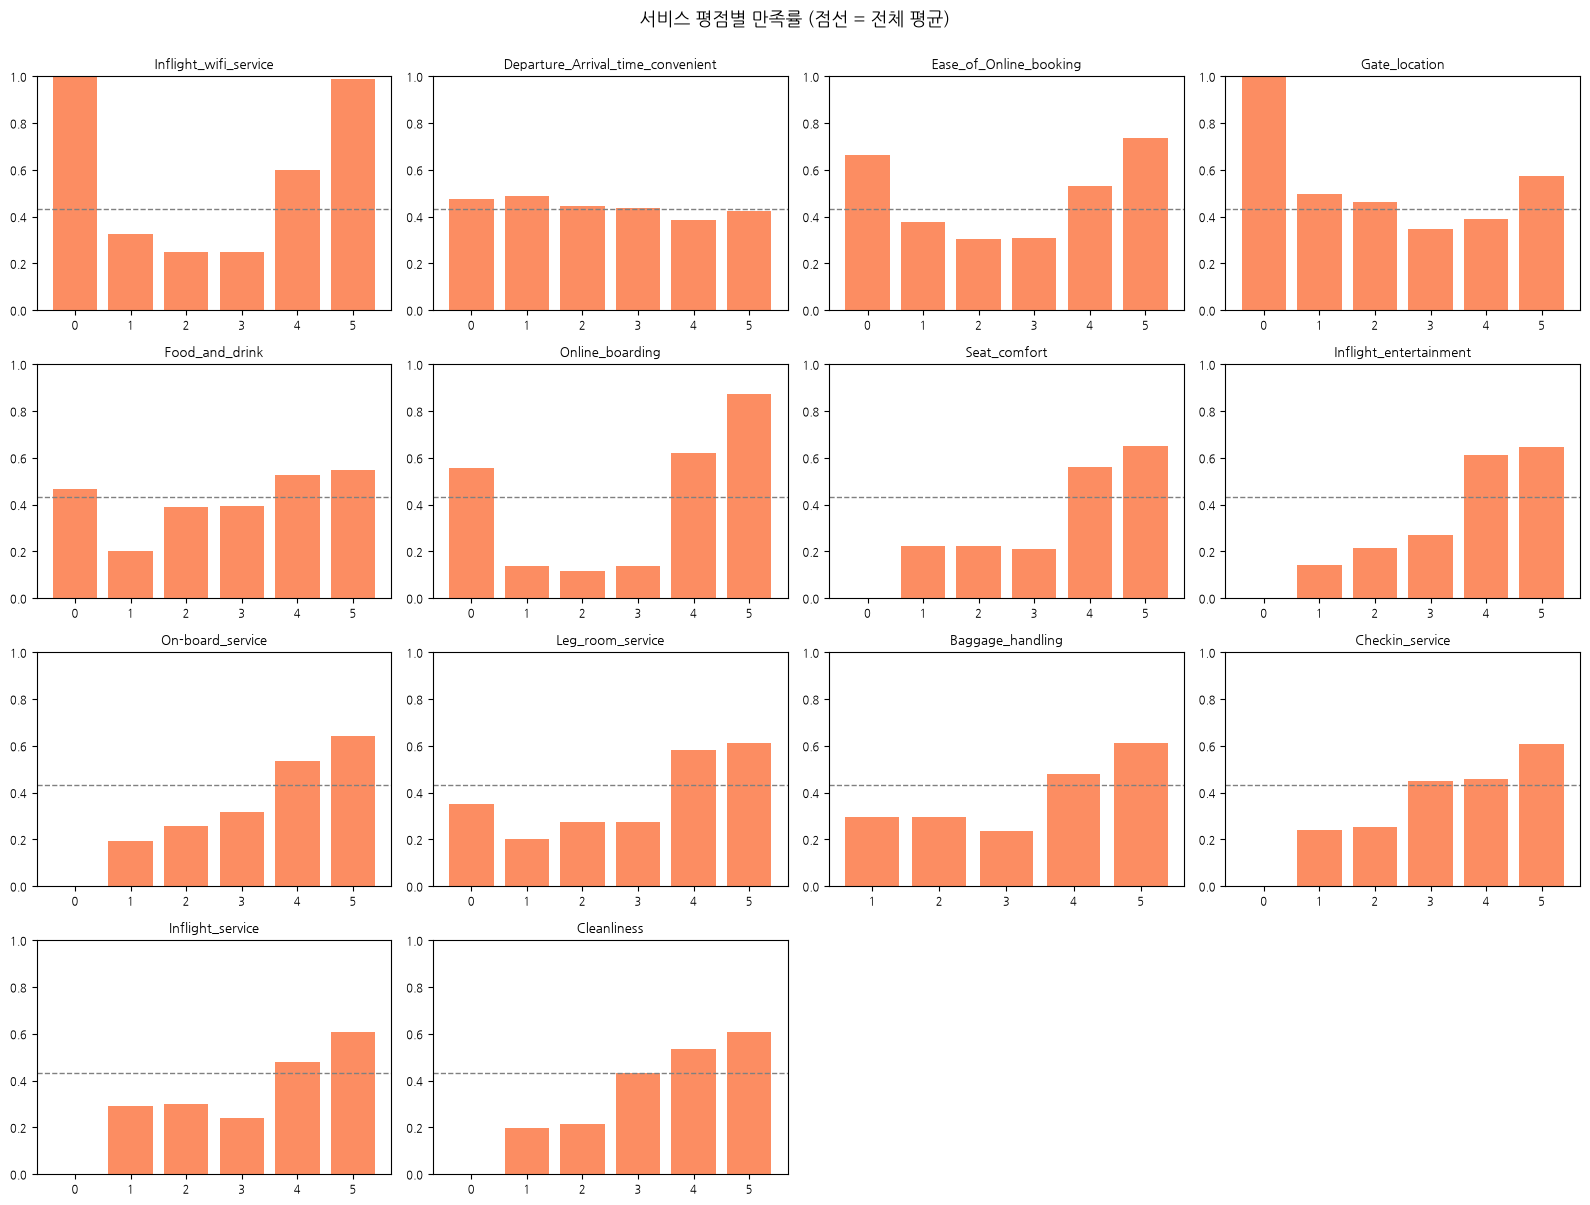

In [102]:
# 서비스 평점별 만족률 (groupby 활용)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.ravel(), rating_cols):
    rate = y_tr_bin.groupby(train_df[col]).mean()
    ax.bar(rate.index.astype(str), rate.values, color=sns.color_palette('Set2')[1])
    ax.axhline(y_tr_bin.mean(), ls='--', c='gray', lw=1)
    ax.set_title(col, fontsize=9); ax.set_ylim(0, 1); ax.tick_params(labelsize=8)
for ax in axes.ravel()[len(rating_cols):]:
    ax.axis('off')
plt.suptitle('서비스 평점별 만족률 (점선 = 전체 평균)', y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

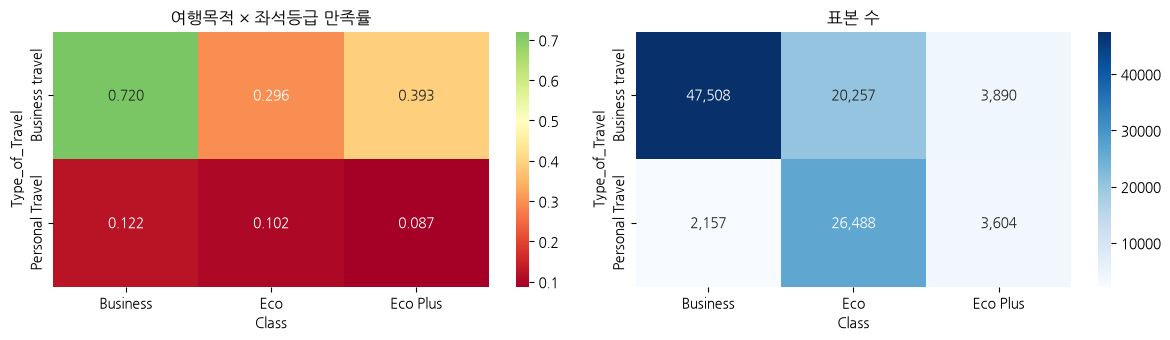

In [103]:
# 여행목적 × 좌석등급 교차 만족률
pivot = train_df.assign(sat=y_tr_bin).pivot_table(
    index='Type_of_Travel', columns='Class', values='sat', aggfunc='mean')
cnt = train_df.pivot_table(index='Type_of_Travel', columns='Class',
                           values='Age', aggfunc='size')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5, ax=ax[0])
ax[0].set_title('여행목적 × 좌석등급 만족률')
sns.heatmap(cnt, annot=True, fmt=',d', cmap='Blues', ax=ax[1])
ax[1].set_title('표본 수')
plt.tight_layout(); plt.show()

In [104]:
MAPS = {
    'Gender':         {'Male': 0, 'Female': 1},
    'Customer_Type':  {'Loyal Customer': 0, 'disloyal Customer': 1},
    'Type_of_Travel': {'Personal Travel': 0, 'Business travel': 1},
    'Class':          {'Eco': 0, 'Eco Plus': 1, 'Business': 2},   # 순서형
    TARGET:           {'neutral or dissatisfied': 0, 'satisfied': 1},
}

for c, m in MAPS.items():
    for d in (train_df, test_df):
        d[c] = d[c].map(m)
    assert train_df[c].notna().all() and test_df[c].notna().all(), f'{c} 매핑 실패'

print('인코딩 완료')
display(train_df.head(3))

인코딩 완료


,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure_Arrival_time_convenient,Ease_of_Online_booking,Gate_location,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,0,0,13,0,1,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,0,1,25,1,2,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,1,0,26,1,2,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1


In [105]:
train_df = train_df.drop(columns=['Arrival_Delay_in_Minutes'])
test_df = test_df.drop(columns=['Arrival_Delay_in_Minutes'])
X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET].to_numpy()
X_test  = test_df.drop(columns=TARGET)
y_test  = test_df[TARGET].to_numpy()

assert TARGET not in X_train.columns, '타겟이 피처에 섞였습니다'
assert X_train.shape[1] == train_df.shape[1] - 1
assert list(X_train.columns) == list(X_test.columns), 'train/test 컬럼 불일치'

FEATURES = X_train.columns.tolist()
print(f'피처 {len(FEATURES)}개')
print(FEATURES)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit은 train에만
X_test_s  = scaler.transform(X_test)        # test는 transform만

# 분포 sanity check — 로그 변환 누락 같은 실수를 잡아냄
chk = pd.DataFrame({
    'train_min': X_train_s.min(0), 'train_max': X_train_s.max(0),
    'test_min':  X_test_s.min(0),  'test_max':  X_test_s.max(0),
}, index=FEATURES)
display(chk.style.format('{:.2f}'))

피처 21개
['Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes']


,train_min,train_max,test_min,test_max
Gender,-1.02,0.99,-1.02,0.99
Customer_Type,-0.47,2.12,-0.47,2.12
Age,-2.14,3.02,-2.14,3.02
Type_of_Travel,-1.49,0.67,-1.49,0.67
Class,-1.07,1.01,-1.07,1.01
Flight_Distance,-1.16,3.80,-1.16,3.80
Inflight_wifi_service,-2.06,1.71,-2.06,1.71
Departure_Arrival_time_convenient,-2.01,1.27,-2.01,1.27
Ease_of_Online_booking,-1.97,1.60,-1.97,1.60
Gate_location,-2.33,1.58,-1.55,1.58


In [106]:
def chi2_rank(Xin):
    s = SelectKBest(chi2, k='all').fit(Xin, y_train)
    return pd.Series(s.scores_, index=FEATURES).sort_values(ascending=False).head(8)

raw_rank = chi2_rank(X_train)
mm_rank  = chi2_rank(MinMaxScaler().fit_transform(X_train))

cmp_df = pd.DataFrame({
    '원본_변수': raw_rank.index,   '원본_chi2': raw_rank.values.round(1),
    'MinMax_변수': mm_rank.index, 'MinMax_chi2': mm_rank.values.round(1),
})
print('chi2 상위 8개 — 스케일링 전후로 순위가 뒤집힘')
display(cmp_df)

chi2 상위 8개 — 스케일링 전후로 순위가 뒤집힘


,원본_변수,원본_chi2,MinMax_변수,MinMax_chi2
0,Flight_Distance,7753602.5,Class,11454.3
1,Departure_Delay_in_Minutes,26134.9,Type_of_Travel,6501.4
2,Class,22908.6,Customer_Type,2990.0
3,Online_boarding,14762.0,Online_boarding,2952.4
4,Age,11341.5,Inflight_entertainment,1742.2
5,Inflight_entertainment,8711.2,Flight_Distance,1607.7
6,Type_of_Travel,6501.4,Seat_comfort,1283.9
7,Seat_comfort,6419.3,Inflight_wifi_service,1084.5


In [107]:
def run_model(name, model, X_tr, y_tr, X_te, y_te, verbose=True):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    took = time.time() - t0

    sub = np.random.RandomState(RS).choice(len(X_tr), 15000, replace=False)
    p_tr, p_te = model.predict(X_tr[sub]), model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    acc_tr = accuracy_score(y_tr[sub], p_tr)   # 15k 샘플 기준
    acc_te = accuracy_score(y_te, p_te)
    auc    = roc_auc_score(y_te, proba)
    rep    = classification_report(y_te, p_te, output_dict=True)
    gap    = acc_tr - acc_te
    flag   = '과적합 의심' if gap > 0.05 else '정상'

    if verbose:
        print(f'{name:22s} train {acc_tr:.4f} | test {acc_te:.4f} | '
              f'AUC {auc:.4f} | F1 {rep["1"]["f1-score"]:.4f} | '
              f'격차 {gap:+.4f} ({flag}) | {took:.1f}s')

    return dict(모델=name, train정확도=acc_tr, test정확도=acc_te, ROC_AUC=auc,
                F1_만족=rep['1']['f1-score'], precision_만족=rep['1']['precision'],
                recall_만족=rep['1']['recall'], 격차=gap, 판정=flag,
                시간초=took, _model=model, _proba=proba, _pred=p_te)


MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RS),
    'KNN (k=5)':          KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'DecisionTree(d=12)': DecisionTreeClassifier(max_depth=12, random_state=RS),
    'RandomForest':       RandomForestClassifier(n_estimators=150, random_state=RS, n_jobs=-1),
    'ExtraTrees':         ExtraTreesClassifier(n_estimators=150, random_state=RS, n_jobs=-1),
    'XGBoost':            XGBClassifier(n_estimators=300, eval_metric='logloss',
                                        random_state=RS, n_jobs=-1),
    'LightGBM':           LGBMClassifier(n_estimators=300, random_state=RS,
                                         n_jobs=-1, verbose=-1),
}

results = []
for name, m in MODELS.items():
    results.append(run_model(name, m, X_train_s, y_train, X_test_s, y_test))

LogisticRegression     train 0.8747 | test 0.8711 | AUC 0.9255 | F1 0.8501 | 격차 +0.0036 (정상) | 0.1s
KNN (k=5)              train 0.9497 | test 0.9302 | AUC 0.9718 | F1 0.9177 | 격차 +0.0196 (정상) | 0.0s
DecisionTree(d=12)     train 0.9625 | test 0.9525 | AUC 0.9854 | F1 0.9450 | 격차 +0.0101 (정상) | 0.4s
RandomForest           train 1.0000 | test 0.9640 | AUC 0.9940 | F1 0.9583 | 격차 +0.0360 (정상) | 1.8s
ExtraTrees             train 1.0000 | test 0.9620 | AUC 0.9932 | F1 0.9560 | 격차 +0.0380 (정상) | 1.5s
XGBoost                train 0.9922 | test 0.9630 | AUC 0.9951 | F1 0.9574 | 격차 +0.0292 (정상) | 1.0s
LightGBM               train 0.9737 | test 0.9649 | AUC 0.9955 | F1 0.9594 | 격차 +0.0088 (정상) | 1.2s


,모델,train정확도,test정확도,ROC_AUC,F1_만족,precision_만족,recall_만족,격차,판정,시간초
0,LightGBM,0.9737,0.9649,0.9955,0.9594,0.9744,0.9449,+0.0088,정상,1.2
1,XGBoost,0.9922,0.9630,0.9951,0.9574,0.9682,0.9469,+0.0292,정상,1.0
2,RandomForest,1.0000,0.9640,0.9940,0.9583,0.9739,0.9433,+0.0360,정상,1.8
3,ExtraTrees,1.0000,0.9620,0.9932,0.9560,0.9713,0.9412,+0.0380,정상,1.5
4,DecisionTree(d=12),0.9625,0.9525,0.9854,0.9450,0.9600,0.9305,+0.0101,정상,0.4
5,KNN (k=5),0.9497,0.9302,0.9718,0.9177,0.9506,0.8870,+0.0196,정상,0.0
6,LogisticRegression,0.8747,0.8711,0.9255,0.8501,0.8682,0.8328,+0.0036,정상,0.1


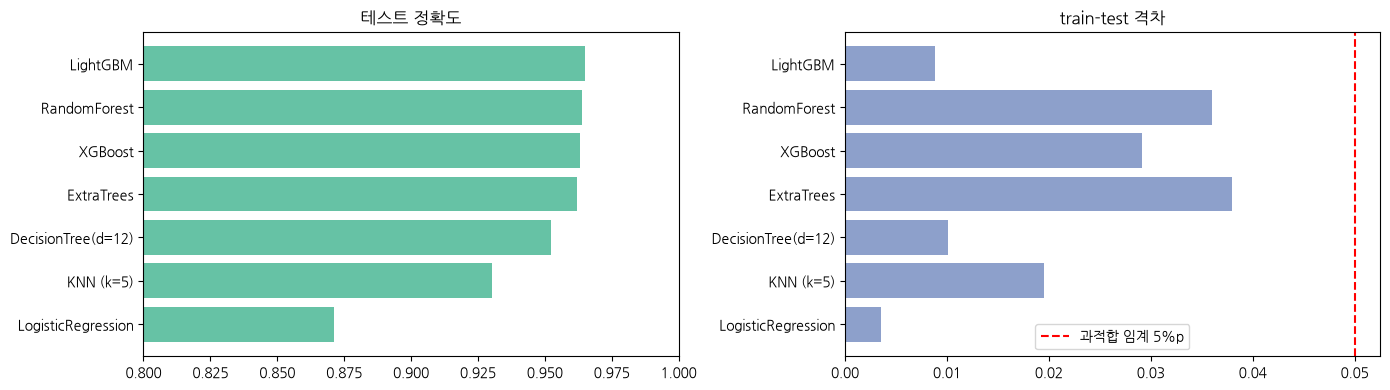

In [108]:
res_df = pd.DataFrame(results).drop(columns=['_model', '_proba', '_pred'])
res_df = res_df.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
display(res_df.style.format({
    'train정확도': '{:.4f}', 'test정확도': '{:.4f}', 'ROC_AUC': '{:.4f}',
    'F1_만족': '{:.4f}', 'precision_만족': '{:.4f}', 'recall_만족': '{:.4f}',
    '격차': '{:+.4f}', '시간초': '{:.1f}'
}).background_gradient(subset=['ROC_AUC'], cmap='Greens'))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
o = res_df.sort_values('test정확도')
ax[0].barh(o['모델'], o['test정확도'], color=sns.color_palette('Set2')[0])
ax[0].set_xlim(0.8, 1.0); ax[0].set_title('테스트 정확도')
ax[1].barh(o['모델'], o['격차'], color=sns.color_palette('Set2')[2])
ax[1].axvline(0.05, ls='--', c='red', label='과적합 임계 5%p')
ax[1].set_title('train-test 격차'); ax[1].legend()
plt.tight_layout(); plt.show()

In [109]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
top3 = res_df.head(3)['모델'].tolist()
print(f'교차검증 대상: {top3}\n')

cv_rows = []
for name in top3:
    t0 = time.time()
    sc = cross_val_score(MODELS[name], X_train_s, y_train,
                         cv=cv, scoring='roc_auc', n_jobs=1)
    cv_rows.append(dict(모델=name, CV평균AUC=sc.mean(), CV표준편차=sc.std(),
                        최소=sc.min(), 최대=sc.max(), 시간초=time.time()-t0))
    print(f'{name:22s} AUC {sc.mean():.4f} ± {sc.std():.4f}   ({time.time()-t0:.0f}s)')

cv_df = pd.DataFrame(cv_rows)
display(cv_df.style.format({'CV평균AUC': '{:.4f}', 'CV표준편차': '{:.4f}',
                            '최소': '{:.4f}', '최대': '{:.4f}', '시간초': '{:.0f}'}))

교차검증 대상: ['LightGBM', 'XGBoost', 'RandomForest']

LightGBM               AUC 0.9953 ± 0.0003   (5s)
XGBoost                AUC 0.9948 ± 0.0004   (4s)
RandomForest           AUC 0.9939 ± 0.0004   (8s)


,모델,CV평균AUC,CV표준편차,최소,최대,시간초
0,LightGBM,0.9953,0.0003,0.9948,0.9957,5
1,XGBoost,0.9948,0.0004,0.9943,0.9954,4
2,RandomForest,0.9939,0.0004,0.9931,0.9943,8


In [110]:
BEST = cv_df.sort_values('CV평균AUC', ascending=False).iloc[0]['모델']
print(f'튜닝 대상: {BEST}')

GRIDS = {
    'LightGBM': {
        'n_estimators': [200, 300, 400],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [31, 63],
        'min_child_samples': [10, 20, 40],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0],
        'reg_lambda': [0, 1, 5],
    },
    'XGBoost': {
        'n_estimators': [200, 300, 400],
        'learning_rate': [0.05, 0.1],
        'max_depth': [5, 7, 9],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0],
    },
    'RandomForest': {
        'n_estimators': [200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
    'ExtraTrees': {
        'n_estimators': [200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
}

# 탐색은 서브샘플(3만 행)로 — 전체로 돌리면 1코어 환경에서 매우 오래 걸립니다.
# 하이퍼파라미터의 상대적 우열은 서브샘플에서도 대체로 보존됩니다.
SEARCH_N = min(30_000, len(X_train_s))
idx = np.random.RandomState(RS).choice(len(X_train_s), SEARCH_N, replace=False)

base = MODELS[BEST]
search = RandomizedSearchCV(
    base, GRIDS[BEST], n_iter=5, cv=3, scoring='roc_auc',
    random_state=RS, n_jobs=1, verbose=0
)
t0 = time.time()
search.fit(X_train_s[idx], y_train[idx])
print(f'탐색 완료 ({time.time()-t0:.0f}s, 서브샘플 {SEARCH_N:,}행)')
print('최적 파라미터:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'탐색 최고 CV AUC: {search.best_score_:.4f}')

# 찾은 파라미터로 전체 훈련 데이터에 다시 학습
best_model = search.best_estimator_.__class__(**{**search.best_estimator_.get_params()})
best_model.fit(X_train_s, y_train)
print(f'\n전체 훈련 데이터({len(X_train_s):,}행)로 재학습 완료')

튜닝 대상: LightGBM
탐색 완료 (21s, 서브샘플 30,000행)
최적 파라미터:
  subsample: 1.0
  reg_lambda: 5
  num_leaves: 63
  n_estimators: 400
  min_child_samples: 20
  learning_rate: 0.05
  colsample_bytree: 0.7
탐색 최고 CV AUC: 0.9939

전체 훈련 데이터(103,904행)로 재학습 완료


In [111]:
tuned = run_model(f'{BEST} (튜닝)', best_model, X_train_s, y_train, X_test_s, y_test)

before = res_df[res_df['모델'] == BEST].iloc[0]
print()
comp = pd.DataFrame({
    '': ['튜닝 전', '튜닝 후'],
    'train정확도': [before['train정확도'], tuned['train정확도']],
    'test정확도':  [before['test정확도'],  tuned['test정확도']],
    'ROC_AUC':     [before['ROC_AUC'],     tuned['ROC_AUC']],
    '격차':        [before['격차'],        tuned['격차']],
}).set_index('')
display(comp.style.format('{:.4f}'))

LightGBM (튜닝)          train 0.9742 | test 0.9664 | AUC 0.9956 | F1 0.9611 | 격차 +0.0078 (정상) | 2.7s



,train정확도,test정확도,ROC_AUC,격차
,,,,
튜닝 전,0.9737,0.9649,0.9955,0.0088
튜닝 후,0.9742,0.9664,0.9956,0.0078


              precision    recall  f1-score   support

   불만족/중립(0)     0.9585    0.9826    0.9704     14573
       만족(1)     0.9771    0.9456    0.9611     11403

    accuracy                         0.9664     25976
   macro avg     0.9678    0.9641    0.9658     25976
weighted avg     0.9667    0.9664    0.9663     25976



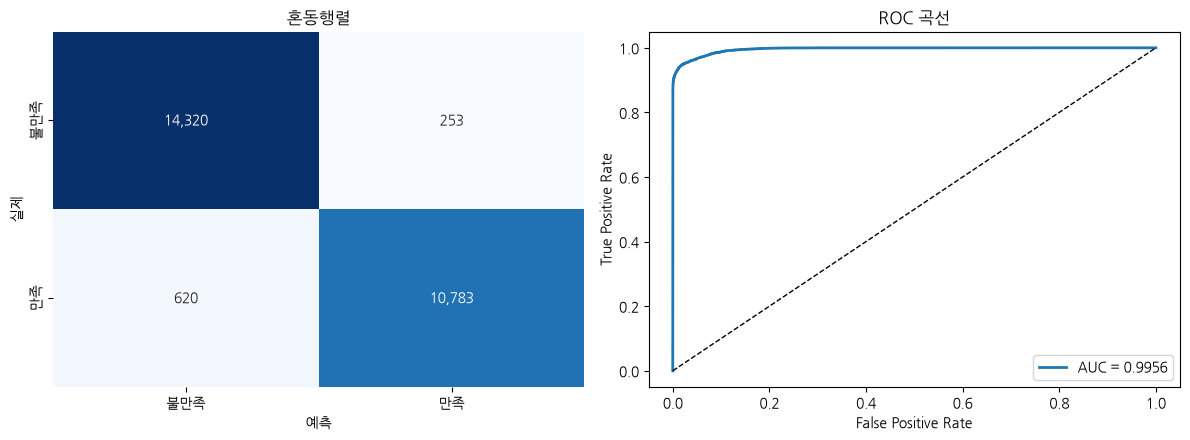

실제 만족인데 불만족으로 예측(FN): 620명
실제 불만족인데 만족으로 예측(FP): 253명


In [112]:
y_pred  = tuned['_pred']
y_proba = tuned['_proba']

print(classification_report(y_test, y_pred, digits=4,
                            target_names=['불만족/중립(0)', '만족(1)']))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['불만족', '만족'], yticklabels=['불만족', '만족'])
ax[0].set_xlabel('예측'); ax[0].set_ylabel('실제'); ax[0].set_title('혼동행렬')

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, lw=2, label=f'AUC = {tuned["ROC_AUC"]:.4f}')
ax[1].plot([0, 1], [0, 1], 'k--', lw=1)
ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC 곡선'); ax[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'실제 만족인데 불만족으로 예측(FN): {fn:,}명')
print(f'실제 불만족인데 만족으로 예측(FP): {fp:,}명')

In [113]:
# (1) 상관
corr_imp = rs.reindex(FEATURES).abs().rename('상관(절댓값)')

# (2) 트리 기반 importance
tree_imp = pd.Series(best_model.feature_importances_, index=FEATURES, name='importance')
tree_imp = tree_imp / tree_imp.sum()

imp_df = pd.concat([corr_imp, tree_imp], axis=1)
imp_df['상관_순위'] = imp_df['상관(절댓값)'].rank(ascending=False)
imp_df['importance_순위'] = imp_df['importance'].rank(ascending=False)
display(imp_df.sort_values('importance', ascending=False)
        .style.format({'상관(절댓값)': '{:.4f}', 'importance': '{:.4f}',
                       '상관_순위': '{:.0f}', 'importance_순위': '{:.0f}'}))

,상관(절댓값),importance,상관_순위,importance_순위
Flight_Distance,0.2988,0.1308,7,1
Age,0.1372,0.1117,14,2
Inflight_wifi_service,0.2842,0.0733,8,3
Departure_Delay_in_Minutes,0.0505,0.0661,16,4
Baggage_handling,0.2477,0.0555,9,5
Inflight_service,0.2447,0.0549,10,6
Gate_location,0.0007,0.0455,17,7
Seat_comfort,0.3495,0.0444,3,8
Inflight_entertainment,0.3981,0.0440,2,9
On-board_service,0.3224,0.0413,4,10


c:\Users\KDT11\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
c:\Users\KDT11\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
C:\Users\KDT11\AppData\Local\Temp\ipykernel_18796\4168995322.py:17: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()


SHAP 계산 2s   shape=(2000, 21)


C:\Users\KDT11\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


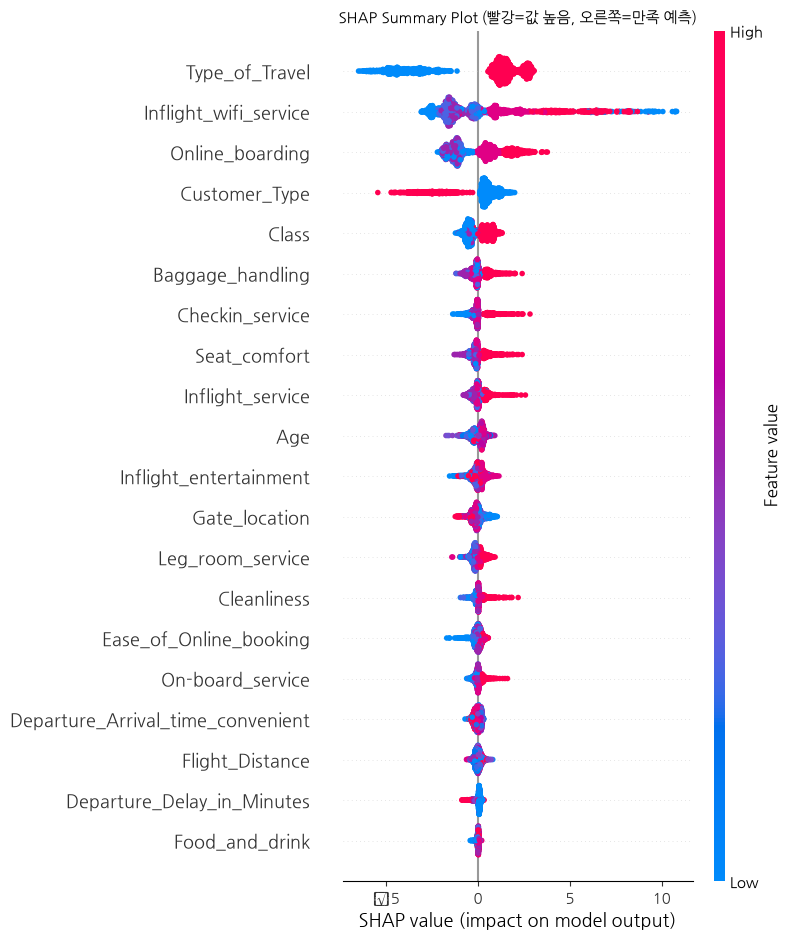

In [114]:
import shap

X_sample = X_test.sample(n=2000, random_state=RS)
X_sample_s = scaler.transform(X_sample)

t0 = time.time()
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample_s)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
print(f'SHAP 계산 {time.time()-t0:.0f}s   shape={shap_values.shape}')

shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False)
plt.title('SHAP Summary Plot (빨강=값 높음, 오른쪽=만족 예측)', fontsize=11)
plt.tight_layout(); plt.show()

,상관순위,importance순위,SHAP순위,평균순위
Inflight_wifi_service,8.0,3.0,2.0,4.3
Online_boarding,1.0,14.0,3.0,6.0
Seat_comfort,3.0,8.0,8.0,6.3
Baggage_handling,9.0,5.0,6.0,6.7
Inflight_entertainment,2.0,9.0,11.0,7.3
Inflight_service,10.0,6.0,9.0,8.3
Flight_Distance,7.0,1.0,18.0,8.7
Age,14.0,2.0,10.0,8.7
Leg_room_service,5.0,11.0,13.0,9.7
Class,nan,15.0,5.0,10.0


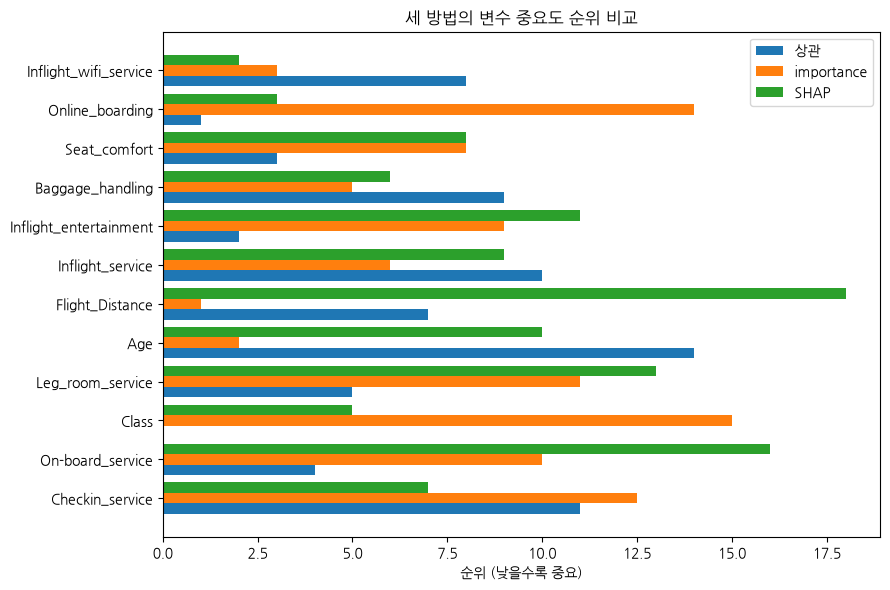

In [115]:
shap_imp = pd.Series(np.abs(shap_values).mean(0), index=FEATURES, name='SHAP')

final = pd.DataFrame({
    '상관순위':       corr_imp.rank(ascending=False),
    'importance순위': tree_imp.rank(ascending=False),
    'SHAP순위':       shap_imp.rank(ascending=False),
})
final['평균순위'] = final.mean(axis=1)
final = final.sort_values('평균순위')
display(final.style.format('{:.1f}').background_gradient(subset=['평균순위'], cmap='Greens_r'))

fig, ax = plt.subplots(figsize=(9, 6))
top = final.head(12).index[::-1]
w = 0.27
yp = np.arange(len(top))
for i, (c, lb) in enumerate([('상관순위', '상관'), ('importance순위', 'importance'), ('SHAP순위', 'SHAP')]):
    ax.barh(yp + (i-1)*w, final.loc[top, c], height=w, label=lb)
ax.set_yticks(yp); ax.set_yticklabels(top)
ax.set_xlabel('순위 (낮을수록 중요)'); ax.legend()
ax.set_title('세 방법의 변수 중요도 순위 비교')
plt.tight_layout(); plt.show()

In [116]:
top4 = final.head(4).index.tolist()
print(f'상위 4개 변수: {top4}\n')

for c in top4:
    g = train_df.groupby(c)[TARGET].agg(['mean', 'size'])
    g.columns = ['만족률', '건수']
    print(f'── {c} ──')
    print(g.to_string(float_format=lambda v: f'{v:.4f}'))
    print()

상위 4개 변수: ['Inflight_wifi_service', 'Online_boarding', 'Seat_comfort', 'Baggage_handling']

── Inflight_wifi_service ──
                         만족률     건수
Inflight_wifi_service              
0                     0.9974   3103
1                     0.3254  17840
2                     0.2487  25830
3                     0.2506  25868
4                     0.5990  19794
5                     0.9908  11469

── Online_boarding ──
                   만족률     건수
Online_boarding              
0               0.5564   2428
1               0.1378  10692
2               0.1153  17505
3               0.1357  21804
4               0.6230  30762
5               0.8718  20713

── Seat_comfort ──
                만족률     건수
Seat_comfort              
0            0.0000      1
1            0.2232  12075
2            0.2241  14897
3            0.2115  18696
4            0.5612  31765
5            0.6502  26470

── Baggage_handling ──
                    만족률     건수
Baggage_handling              
1      

In [117]:
print('=' * 66)
print('  항공 승객 만족도 예측 — 최종 요약')
print('=' * 66)
print(f'  데이터        train {X_train.shape[0]:,} / test {X_test.shape[0]:,} · 피처 {len(FEATURES)}개')
print(f'  최종 모델     {BEST} (RandomizedSearchCV 튜닝)')
print(f'  테스트 정확도 {tuned["test정확도"]:.4f}')
print(f'  ROC-AUC       {tuned["ROC_AUC"]:.4f}')
print(f'  F1 (만족)     {tuned["F1_만족"]:.4f}')
print(f'  train-test 격차 {tuned["격차"]:+.4f} → {tuned["판정"]}')
print('-' * 66)
print('  핵심 변수 (3중 교차검증 평균순위 상위 5)')
for i, (n, r) in enumerate(final.head(5)['평균순위'].items(), 1):
    print(f'    {i}. {n:32s} (평균순위 {r:.1f})')
print('=' * 66)

  항공 승객 만족도 예측 — 최종 요약
  데이터        train 103,904 / test 25,976 · 피처 21개
  최종 모델     LightGBM (RandomizedSearchCV 튜닝)
  테스트 정확도 0.9664
  ROC-AUC       0.9956
  F1 (만족)     0.9611
  train-test 격차 +0.0078 → 정상
------------------------------------------------------------------
  핵심 변수 (3중 교차검증 평균순위 상위 5)
    1. Inflight_wifi_service            (평균순위 4.3)
    2. Online_boarding                  (평균순위 6.0)
    3. Seat_comfort                     (평균순위 6.3)
    4. Baggage_handling                 (평균순위 6.7)
    5. Inflight_entertainment           (평균순위 7.3)


In [30]:
import numpy as np

y_true      = np.asarray(y_test).ravel()
is_personal = (X_test['Type_of_Travel'] == 0).values

yp = y_true[is_personal]

print('yp 길이:', len(yp))          # 6456 이어야 정상
print('만족 고객 수:', yp.sum())     # 607 근처
print('만족률:', yp.mean().round(4)) # 0.0940

yp 길이: 6456
만족 고객 수: 607
만족률: 0.094


In [31]:
from sklearn.metrics import recall_score, f1_score
is_personal = (X_test['Type_of_Travel'] == 0).values
base_cols = [c for c in X_train.columns]
def evaluate(cols, label):
    m = LGBMClassifier(random_state=42, verbose=-1).fit(X_train[cols], y_train)
    pred = m.predict(X_test[cols])
    pp   = pred[is_personal]
    print(f'{label:12s} 전체 {m.score(X_test[cols], y_test):.4f} | '
          f'Personal 재현율 {recall_score(yp, pp, zero_division=0):.4f} | '
          f'F1 {f1_score(yp, pp, zero_division=0):.4f}')
    return m

m_base = evaluate(base_cols, '기준(22개)')

기준(22개)      전체 0.9644 | Personal 재현율 0.5997 | F1 0.7497


In [32]:
import numpy as np, pandas as pd

SVC = ['Inflight_wifi_service', 'Departure_Arrival_time_convenient',
       'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink',
       'Online_boarding', 'Seat_comfort', 'Inflight_entertainment',
       'On-board_service', 'Leg_room_service', 'Baggage_handling',
       'Checkin_service', 'Inflight_service', 'Cleanliness']

SVC = [c for c in SVC if c in base_cols]        # 존재 확인
print(f'{len(SVC)}개 항목:', SVC)

Xb = X_test[base_cols]                          # 상호작용 컬럼 제외
base_rate = m_base.predict_proba(Xb)[:, 1].mean()
print(f'현재 예측 만족률: {base_rate:.4f}')

14개 항목: ['Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness']
현재 예측 만족률: 0.4364


In [33]:
rows = []
for c in SVC:
    Xc = Xb.copy()
    used = Xc[c] >= 1                            # 0점(미이용)은 제외 — 아래 설명 참조
    Xc.loc[used, c] = np.minimum(Xc.loc[used, c] + 1, 5)

    new_rate = m_base.predict_proba(Xc)[:, 1].mean()
    rows.append({
        '항목'          : c,
        '현재_평균평점' : Xb.loc[used, c].mean(),
        '개선효과_%p'   : (new_rate - base_rate) * 100,
        '대상비율'      : used.mean(),
        '이미5점_비율'  : (Xb[c] == 5).mean(),
    })

sim = pd.DataFrame(rows).set_index('항목').sort_values('개선효과_%p', ascending=False)
sim['우선순위점수'] = sim['개선효과_%p'] / sim['현재_평균평점']
display(sim.round(3))

,현재_평균평점,개선효과_%p,대상비율,이미5점_비율,우선순위점수
항목,,,,,
Inflight_wifi_service,2.811,11.956,0.969,0.110,4.254
Online_boarding,3.331,4.150,0.977,0.200,1.246
Baggage_handling,3.626,3.157,1.000,0.260,0.871
Checkin_service,3.308,3.144,1.000,0.202,0.951
Inflight_service,3.640,2.825,1.000,0.262,0.776
Seat_comfort,3.452,2.597,1.000,0.256,0.752
Cleanliness,3.285,1.922,1.000,0.214,0.585
On-board_service,3.383,0.969,1.000,0.224,0.287
Leg_room_service,3.379,0.378,0.995,0.237,0.112


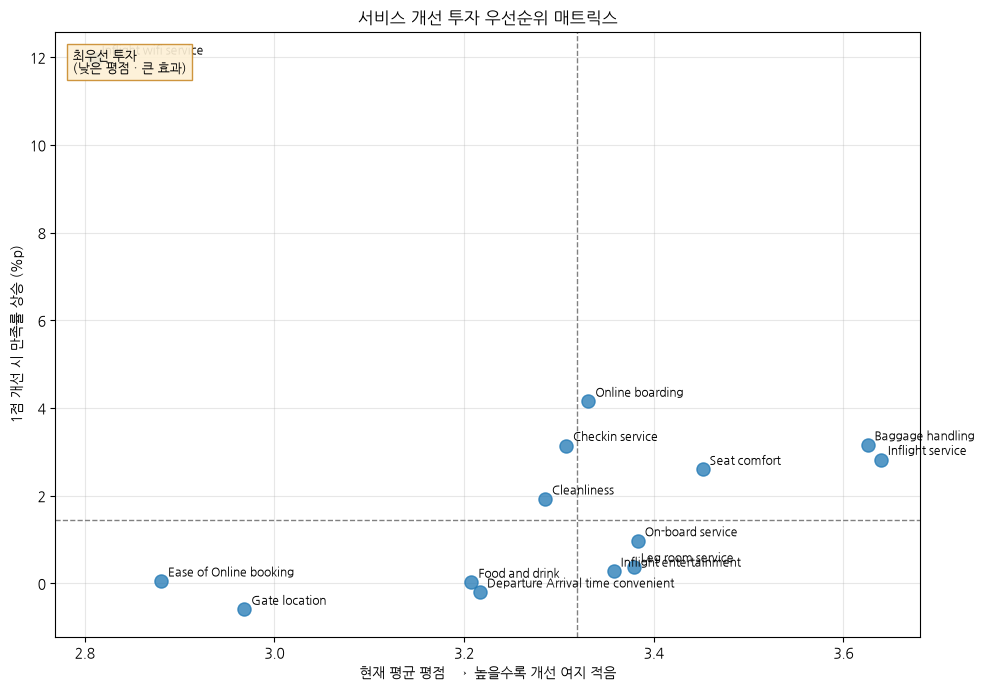

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(sim['현재_평균평점'], sim['개선효과_%p'], s=90, alpha=.75, zorder=3)

for name, r in sim.iterrows():
    ax.annotate(name.replace('_', ' '), (r['현재_평균평점'], r['개선효과_%p']),
                fontsize=8.5, xytext=(5, 4), textcoords='offset points')

ax.axvline(sim['현재_평균평점'].median(), color='gray', ls='--', lw=1)
ax.axhline(sim['개선효과_%p'].median(), color='gray', ls='--', lw=1)
ax.set_xlabel('현재 평균 평점  →  높을수록 개선 여지 적음')
ax.set_ylabel('1점 개선 시 만족률 상승 (%p)')
ax.set_title('서비스 개선 투자 우선순위 매트릭스')
ax.text(0.02, 0.97, '최우선 투자\n(낮은 평점 · 큰 효과)', transform=ax.transAxes,
        va='top', fontsize=9, bbox=dict(fc='#fdf0d5', ec='#c98a2b', alpha=.9))
ax.grid(alpha=.3, zorder=0)
plt.tight_layout()

In [35]:
seg_res = {}
for label, mask in [('Personal', Xb['Type_of_Travel'] == 0),
                    ('Business', Xb['Type_of_Travel'] == 1)]:
    Xs = Xb[mask.values]
    b = m_base.predict_proba(Xs)[:, 1].mean()
    eff = {}
    for c in SVC:
        Xc = Xs.copy()
        u = Xc[c] >= 1
        Xc.loc[u, c] = np.minimum(Xc.loc[u, c] + 1, 5)
        eff[c] = (m_base.predict_proba(Xc)[:, 1].mean() - b) * 100
    seg_res[label] = pd.Series(eff)

seg_df = pd.DataFrame(seg_res)
seg_df['격차'] = seg_df['Personal'] - seg_df['Business']
print(seg_df.sort_values('격차', ascending=False).round(3).to_string())

                                   Personal  Business      격차
Inflight_wifi_service                19.802     8.419  11.382
Gate_location                        -0.074    -0.829   0.755
Departure_Arrival_time_convenient    -0.144    -0.225   0.081
Ease_of_Online_booking                0.043     0.055  -0.012
Food_and_drink                       -0.015     0.040  -0.055
Inflight_entertainment                0.006     0.397  -0.391
Leg_room_service                      0.073     0.516  -0.442
On-board_service                     -0.006     1.409  -1.415
Cleanliness                           0.007     2.785  -2.778
Seat_comfort                          0.006     3.765  -3.760
Inflight_service                      0.062     4.070  -4.009
Checkin_service                       0.063     4.533  -4.470
Baggage_handling                      0.064     4.551  -4.487
Online_boarding                      -0.058     6.047  -6.105


In [36]:
from lightgbm import LGBMClassifier

# X_train도 배열이라면 DataFrame으로 복원
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=X_test.columns)
best_model = LGBMClassifier(random_state=42, verbose=-1).fit(X_train, y_train)

# 검증
print('피처 이름:', best_model.feature_name_[:3], '...')   # 실제 컬럼명이 나와야 함
print('정확도  :', round(best_model.score(X_test, y_test), 4))   # 0.966 근처

top6 = sim.sort_values('개선효과_%p', ascending=False).head(6).index.to_list() + ['Type_of_Travel', 'Class']
slim = LGBMClassifier().fit(X_train[top6], y_train)
print('전체 22개 변수:', best_model.score(X_test, y_test))
print('핵심 8개 변수 :', slim.score(X_test[top6], y_test))

피처 이름: ['Gender', 'Customer_Type', 'Age'] ...
정확도  : 0.9644
전체 22개 변수: 0.9644386699388865
핵심 8개 변수 : 0.9417737356238872


k=2  실루엣 0.1826  CH 24,793  DB 1.9817  최소군집 0.443
k=3  실루엣 0.1493  CH 19,880  DB 1.9964  최소군집 0.303
k=4  실루엣 0.1485  CH 17,984  DB 1.9296  최소군집 0.235
k=5  실루엣 0.1410  CH 15,394  DB 2.0043  최소군집 0.140
k=6  실루엣 0.1320  CH 13,873  DB 2.0789  최소군집 0.120
k=7  실루엣 0.1296  CH 12,832  DB 2.0278  최소군집 0.122
k=8  실루엣 0.1281  CH 11,854  DB 1.9895  최소군집 0.099
선택된 군집 수 K = 4

실루엣 계수      0.1485
Calinski-Harabasz 17,984
Davies-Bouldin   1.9296
→ 판정: 군집 구조가 약함 — 해석에 주의 필요


,건수,비율
cluster,,
0,24444,0.2353
1,29641,0.2853
2,24974,0.2404
3,24845,0.2391


,실루엣평균,표준편차,표본수
cluster,,,
0,0.1516,0.0956,2344
1,0.2152,0.1061,2855
2,0.0859,0.0843,2415
3,0.1291,0.0963,2386


C:\Users\KDT11\AppData\Local\Temp\ipykernel_18796\1059018729.py:77: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\KDT11\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


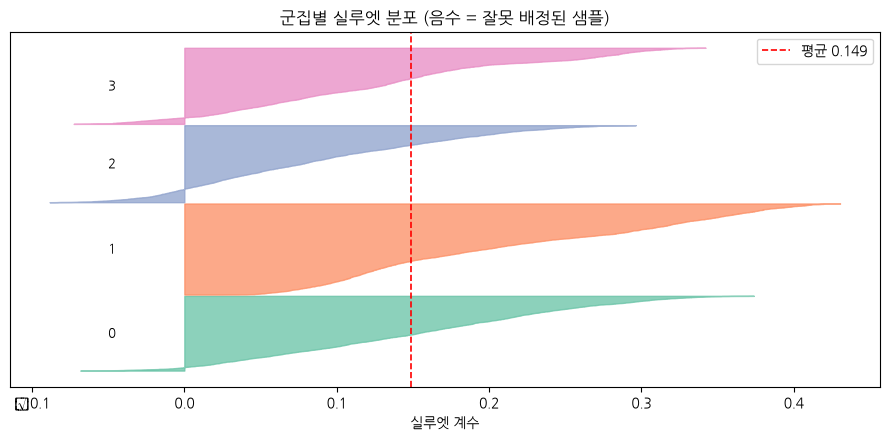

In [118]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score)
clu_df = train_df.copy()
ks = range(2, 9)
rows = []
clu_scaler = StandardScaler()
RS=42
CLUSTER_COLS = list(rating_cols)
X_clu = clu_scaler.fit_transform(clu_df[CLUSTER_COLS])
rng = np.random.RandomState(RS)
sil_idx = rng.choice(len(X_clu), size=min(10000, len(X_clu)), replace=False)
for k in ks:
    km  = KMeans(n_clusters=k, random_state=RS, n_init=10)
    lab = km.fit_predict(X_clu)
    rows.append({
        'k'      : k,
        'inertia': km.inertia_,
        '실루엣' : silhouette_score(X_clu[sil_idx], lab[sil_idx]),
        'CH'     : calinski_harabasz_score(X_clu, lab),
        'DB'     : davies_bouldin_score(X_clu, lab),
        '최소군집비율': np.bincount(lab).min() / len(lab),
    })
    print(f"k={k}  실루엣 {rows[-1]['실루엣']:.4f}  "
          f"CH {rows[-1]['CH']:,.0f}  DB {rows[-1]['DB']:.4f}  "
          f"최소군집 {rows[-1]['최소군집비율']:.3f}")

k_df = pd.DataFrame(rows).set_index('k')
# ── 9-2. 최종 군집 학습 및 품질 판정 ──────────────────────
# K = int(k_df['실루엣'].idxmax())          # 필요하면 수동 지정: K = 4
K=4
print(f'선택된 군집 수 K = {K}\n')

kmeans = KMeans(n_clusters=K, random_state=RS, n_init=10)
labels = kmeans.fit_predict(X_clu)
clu_df['cluster'] = labels

sil_avg = silhouette_score(X_clu[sil_idx], labels[sil_idx])
ch_val  = calinski_harabasz_score(X_clu, labels)
db_val  = davies_bouldin_score(X_clu, labels)

print(f'실루엣 계수      {sil_avg:.4f}')
print(f'Calinski-Harabasz {ch_val:,.0f}')
print(f'Davies-Bouldin   {db_val:.4f}')

# 판정 기준 (실루엣)
if   sil_avg >= 0.50: verdict = '군집이 뚜렷하게 분리됨'
elif sil_avg >= 0.25: verdict = '어느 정도 구조는 있으나 경계가 흐림'
else:                 verdict = '군집 구조가 약함 — 해석에 주의 필요'
print(f'→ 판정: {verdict}')

size = pd.Series(np.bincount(labels), name='건수').to_frame()
size['비율'] = (size['건수'] / size['건수'].sum()).round(4)
size.index.name = 'cluster'
display(size)

# 군집별 실루엣 분포 — 특정 군집만 나쁜지 확인
sil_s = silhouette_samples(X_clu[sil_idx], labels[sil_idx])
per_clu = pd.Series(sil_s).groupby(labels[sil_idx]).agg(['mean', 'std', 'size'])
per_clu.columns = ['실루엣평균', '표준편차', '표본수']
per_clu.index.name = 'cluster'
display(per_clu.style.format({'실루엣평균': '{:.4f}', '표준편차': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(9, 4.5))
y_low = 0
for c in range(K):
    v = np.sort(sil_s[labels[sil_idx] == c])
    ax.fill_betweenx(np.arange(y_low, y_low + len(v)), 0, v, alpha=.75,
                     color=sns.color_palette('Set2')[c % 8])
    ax.text(-0.05, y_low + len(v) / 2, str(c), va='center', fontsize=9)
    y_low += len(v) + 40
ax.axvline(sil_avg, color='red', ls='--', lw=1.2, label=f'평균 {sil_avg:.3f}')
ax.set_xlabel('실루엣 계수'); ax.set_yticks([])
ax.set_title('군집별 실루엣 분포 (음수 = 잘못 배정된 샘플)')
ax.legend(); plt.tight_layout(); plt.show()

c:\Users\KDT11\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.draw()
C:\Users\KDT11\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


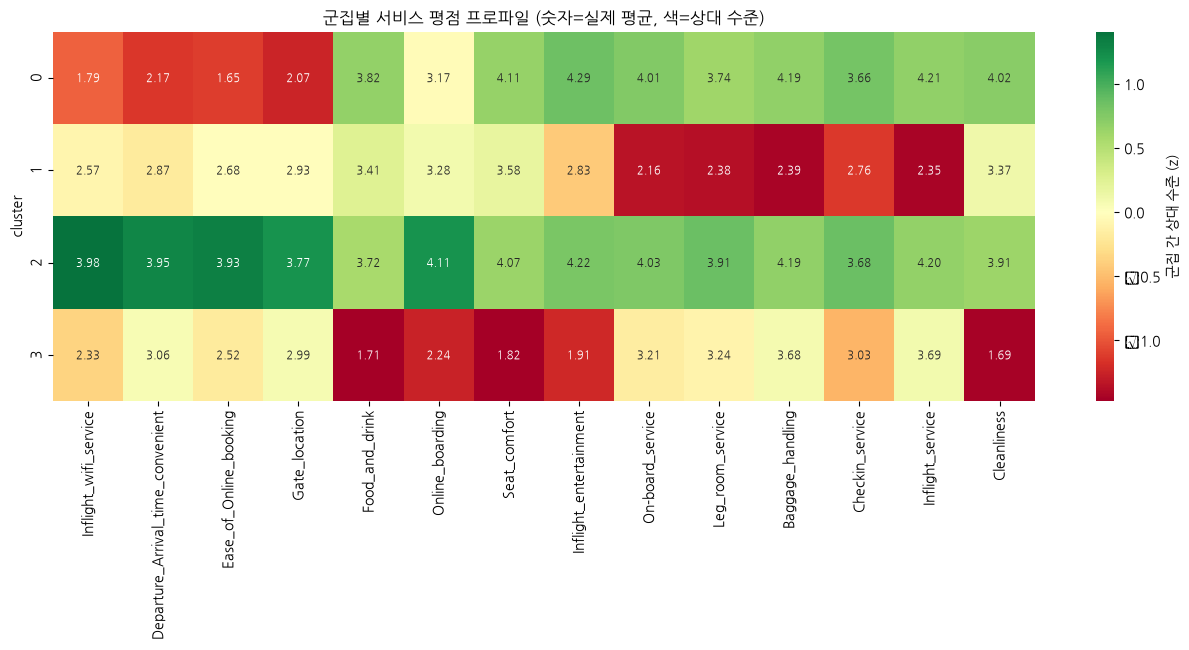

,건수,비율,만족률,비즈니스여행비율,충성고객비율,평균좌석등급,평균연령,평균비행거리,평균지연분
cluster,,,,,,,,,
0,"19,808",0.238,0.5513,0.717,0.835,1.23,40.0,"1,292",13.2
1,"20,033",0.241,0.2277,0.661,0.843,0.84,41.9,"1,116",15.8
2,"23,870",0.287,0.7351,0.789,0.873,1.33,41.2,"1,378",13.7
3,"19,412",0.234,0.1541,0.569,0.703,0.64,34.0,918,17.1



전체 만족률 0.4333
군집별 만족률 범위 0.1541 ~ 0.7351 (격차 0.5810)


In [39]:
# ── 9-4. 군집 프로파일링 ──────────────────────────────────
#  각 군집이 어떤 승객인지 — 평점 패턴 + 인구통계 + 만족률
# ------------------------------------------------------------
prof = clu_df.groupby('cluster')[CLUSTER_COLS].mean()

# z-score로 변환해야 '이 군집의 상대적 강점/약점'이 보인다
zprof = (prof - prof.mean()) / prof.std()

fig, ax = plt.subplots(figsize=(13, 1.1 * K + 2.2))
sns.heatmap(zprof, annot=prof.round(2), fmt='.2f', cmap='RdYlGn', center=0,
            annot_kws={'size': 8}, cbar_kws={'label': '군집 간 상대 수준 (z)'})
ax.set_title('군집별 서비스 평점 프로파일 (숫자=실제 평균, 색=상대 수준)', fontsize=12)
ax.set_xlabel(''); ax.set_ylabel('cluster')
plt.tight_layout(); plt.show()

summary = clu_df.groupby('cluster').agg(
    건수            =(TARGET, 'size'),
    만족률          =(TARGET, 'mean'),
    평균연령        =('Age', 'mean'),
    평균비행거리    =('Flight_Distance', 'mean'),
    비즈니스여행비율=('Type_of_Travel', 'mean'),
    충성고객비율    =('Customer_Type', lambda s: (s == 0).mean()),
    평균좌석등급    =('Class', 'mean'),
    평균지연분      =('Departure_Delay_in_Minutes', 'mean'),
)
summary['비율'] = summary['건수'] / summary['건수'].sum()
summary = summary[['건수', '비율', '만족률', '비즈니스여행비율', '충성고객비율',
                   '평균좌석등급', '평균연령', '평균비행거리', '평균지연분']]

display(summary.style.format({
    '건수': '{:,}', '비율': '{:.3f}', '만족률': '{:.4f}',
    '비즈니스여행비율': '{:.3f}', '충성고객비율': '{:.3f}',
    '평균좌석등급': '{:.2f}', '평균연령': '{:.1f}',
    '평균비행거리': '{:,.0f}', '평균지연분': '{:.1f}',
}).background_gradient(subset=['만족률'], cmap='RdYlGn'))

print(f'\n전체 만족률 {clu_df[TARGET].mean():.4f}')
print(f'군집별 만족률 범위 {summary["만족률"].min():.4f} ~ {summary["만족률"].max():.4f} '
      f'(격차 {summary["만족률"].max() - summary["만족률"].min():.4f})')

In [135]:
# ── 군집 특성의 통계적 근거 검증 (효과크기 eta²) ──────────
import numpy as np, pandas as pd
from scipy.stats import f_oneway

# 군집을 만든 재료 (평점) — 이미 정의돼 있으면 그것을 사용
RATING_COLS = globals().get('CLUSTER_COLS') or globals().get('rating_cols') or [
    'Inflight_wifi_service','Departure_Arrival_time_convenient','Ease_of_Online_booking',
    'Gate_location','Food_and_drink','Online_boarding','Seat_comfort','Inflight_entertainment',
    'On-board_service','Leg_room_service','Baggage_handling','Checkin_service',
    'Inflight_service','Cleanliness']
RATING_COLS = [c for c in RATING_COLS if c in clu_df.columns]

# 사후 프로파일링 변수 (군집 생성에 쓰지 않은 인구통계·여행속성)
DEM_COLS = [c for c in ['Age','Flight_Distance','Departure_Delay_in_Minutes',
                        'Arrival_Delay_in_Minutes','Class','Type_of_Travel',
                        'Customer_Type','Gender']
            if c in clu_df.columns and c not in RATING_COLS]

print(f'군집 재료 {len(RATING_COLS)}개 / 사후 프로파일 {len(DEM_COLS)}개')
print(f'사후 프로파일: {DEM_COLS}\n')


def eta_squared(df, cols, group='cluster'):
    """집단 간 차이의 효과크기. eta² = 집단간 분산 / 전체 분산"""
    ks = sorted(df[group].unique())
    rows = []
    for c in cols:
        groups = [df.loc[df[group] == k, c].dropna().values for k in ks]
        if min(len(g) for g in groups) < 2:
            continue
        gm  = df[c].mean()
        ssb = sum(len(g) * (g.mean() - gm) ** 2 for g in groups)
        sst = ((df[c] - gm) ** 2).sum()
        e2  = ssb / sst if sst > 0 else np.nan
        F, p = f_oneway(*groups)
        means = [g.mean() for g in groups]
        rows.append({
            '변수': c, 'eta2': e2, 'p값': p,
            '최대-최소': max(means) - min(means),
            'Cohen_d': (max(means) - min(means)) / df[c].std(),
            '판정': '강한 구분자' if e2 >= 0.14 else ('언급 가능' if e2 >= 0.06 else '근거 부족'),
        })
    return pd.DataFrame(rows).set_index('변수').sort_values('eta2', ascending=False)


print('■ 군집 재료(평점)의 효과크기 — 당연히 커야 정상')
eta_rating = eta_squared(clu_df, RATING_COLS)
display(eta_rating.round(4))

print('\n■ 사후 프로파일 변수의 효과크기 — 여기서 통과한 것만 특성 서술에 사용')
eta_dem = eta_squared(clu_df, DEM_COLS)
display(eta_dem.round(4))

usable = eta_dem[eta_dem['eta2'] >= 0.06].index.tolist()
dropped = eta_dem[eta_dem['eta2'] < 0.06].index.tolist()
print(f'\n  ✔ 특성 서술에 쓸 수 있는 변수: {usable if usable else "없음"}')
print(f'  ✘ 평균값 차이가 보여도 근거가 부족한 변수: {dropped}')

print('\n■ 요약 — 무엇이 군집을 가르는가')
print(pd.DataFrame({
    '구분'   : ['군집 재료(평점)', '사후 프로파일'],
    '변수 수': [len(eta_rating), len(eta_dem)],
    '평균 eta2': [eta_rating['eta2'].mean(), eta_dem['eta2'].mean()],
    '최대 eta2': [eta_rating['eta2'].max(),  eta_dem['eta2'].max()],
}).set_index('구분').round(4).to_string())


# ── 군집 특성 자동 서술 (근거 있는 변수만 사용) ─────────────
prof  = clu_df.groupby('cluster')[RATING_COLS].mean()
zprof = (prof - prof.mean()) / prof.std()
sat   = clu_df.groupby('cluster')['satisfaction'].agg(['mean', 'size'])

print('\n' + '=' * 62)
print('  군집별 특성 (평점 프로파일 기준)')
print('=' * 62)
for c in sat.sort_values('mean', ascending=False).index:
    z = zprof.loc[c]
    strong = ', '.join(f'{i}({prof.loc[c, i]:.1f})' for i in z.nlargest(3).index)
    weak   = ', '.join(f'{i}({prof.loc[c, i]:.1f})' for i in z.nsmallest(3).index)
    print(f'\n[군집 {c}]  {sat.loc[c,"size"]:,}명 · 만족률 {sat.loc[c,"mean"]:.1%}')
    print(f'  강점  {strong}')
    print(f'  약점  {weak}')
    if usable:
        extra = ' · '.join(f'{v} {clu_df.loc[clu_df.cluster==c, v].mean():.2f}' for v in usable)
        print(f'  참고  {extra}   (eta2 >= 0.06 통과 변수만)')
print('\n' + '=' * 62)

군집 재료 14개 / 사후 프로파일 7개
사후 프로파일: ['Age', 'Flight_Distance', 'Departure_Delay_in_Minutes', 'Class', 'Type_of_Travel', 'Customer_Type', 'Gender']

■ 군집 재료(평점)의 효과크기 — 당연히 커야 정상


,eta2,p값,최대-최소,Cohen_d,판정
변수,,,,,
Inflight_entertainment,0.5480,0.0,2.3719,1.7793,강한 구분자
Cleanliness,0.4856,0.0,2.3179,1.7663,강한 구분자
Seat_comfort,0.4840,0.0,2.2852,1.7324,강한 구분자
Inflight_service,0.4122,0.0,1.8686,1.5894,강한 구분자
Inflight_wifi_service,0.3990,0.0,2.1920,1.6508,강한 구분자
Food_and_drink,0.3941,0.0,2.1011,1.5804,강한 구분자
Baggage_handling,0.3899,0.0,1.8196,1.5409,강한 구분자
Ease_of_Online_booking,0.3576,0.0,2.2771,1.6277,강한 구분자
On-board_service,0.3480,0.0,1.8613,1.4447,강한 구분자



■ 사후 프로파일 변수의 효과크기 — 여기서 통과한 것만 특성 서술에 사용


,eta2,p값,최대-최소,Cohen_d,판정
변수,,,,,
Class,0.0877,0.0,0.6987,0.7257,언급 가능
Age,0.0401,0.0,7.7878,0.5152,근거 부족
Flight_Distance,0.0327,0.0,465.8937,0.4672,근거 부족
Type_of_Travel,0.0321,0.0,0.2239,0.4839,근거 부족
Customer_Type,0.0283,0.0,0.1703,0.4408,근거 부족
Gender,0.0048,0.0,0.0996,0.1992,근거 부족
Departure_Delay_in_Minutes,0.0017,0.0,3.9250,0.1027,근거 부족



  ✔ 특성 서술에 쓸 수 있는 변수: ['Class']
  ✘ 평균값 차이가 보여도 근거가 부족한 변수: ['Age', 'Flight_Distance', 'Type_of_Travel', 'Customer_Type', 'Gender', 'Departure_Delay_in_Minutes']

■ 요약 — 무엇이 군집을 가르는가
           변수 수  평균 eta2  최대 eta2
구분                               
군집 재료(평점)    14   0.3418   0.5480
사후 프로파일       7   0.0325   0.0877

  군집별 특성 (평점 프로파일 기준)

[군집 1]  29,641명 · 만족률 73.6%
  강점  Inflight_wifi_service(4.0), Ease_of_Online_booking(3.9), Departure_Arrival_time_convenient(4.0)
  약점  Food_and_drink(3.7), Cleanliness(3.9), Seat_comfort(4.1)
  참고  Class 1.34   (eta2 >= 0.06 통과 변수만)

[군집 3]  24,845명 · 만족률 55.4%
  강점  Inflight_entertainment(4.3), Checkin_service(3.7), On-board_service(4.0)
  약점  Gate_location(2.1), Departure_Arrival_time_convenient(2.2), Ease_of_Online_booking(1.7)
  참고  Class 1.23   (eta2 >= 0.06 통과 변수만)

[군집 2]  24,974명 · 만족률 22.9%
  강점  Food_and_drink(3.4), Seat_comfort(3.6), Cleanliness(3.4)
  약점  Inflight_service(2.4), Baggage_handling(2.4), Leg_room_service(2.4)
  참고  Class 0

[군집 2]  23,870명 · 만족률 73.5%
  강점  wifi(4.0), 온라인예약(3.9), 시간편의(4.0)
  약점  기내식(3.7), 청결도(3.9), 좌석(4.1)        ← 약점도 3.7 이상 (전방위 우수)
  참고  Class 1.33

[군집 0]  19,808명 · 만족률 55.1%
  강점  엔터테인먼트(4.3), 체크인(3.7), 기내서비스(4.0)
  약점  게이트(2.1), 시간편의(2.2), 온라인예약(1.7)   ← 공항·디지털 접점 결핍
  참고  Class 1.23

[군집 1]  20,033명 · 만족률 22.8%
  강점  기내식(3.4), 좌석(3.6), 청결도(3.4)
  약점  기내서비스(2.4), 수하물(2.4), 다리공간(2.4)   ← 인적 응대 결핍
  참고  Class 0.84

[군집 3]  19,412명 · 만족률 15.4%
  강점  기내서비스(3.7), 수하물(3.7), 게이트(3.0)
  약점  기내식(1.7), 좌석(1.8), 청결도(1.7)          ← 물리적 환경 붕괴
  참고  Class 0.64

c:\Users\KDT11\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.draw()
C:\Users\KDT11\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


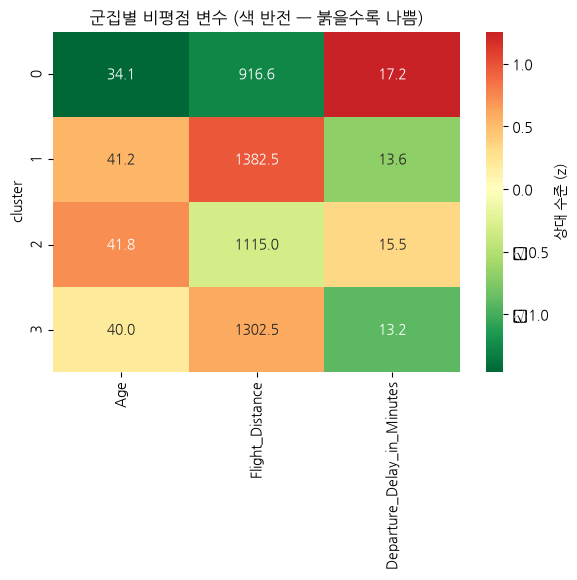

In [125]:
clu_input = train_df[rating_cols].copy()
clu_input['log_delay'] = np.log1p(train_df['Departure_Delay_in_Minutes'])
X_clu2 = StandardScaler().fit_transform(clu_input)

extra = ['Age', 'Flight_Distance', 'Departure_Delay_in_Minutes']
ep = clu_df.groupby('cluster')[extra].mean()
ez = (ep - ep.mean()) / ep.std()

fig, ax = plt.subplots(figsize=(6, 1.1*K + 1.5))
sns.heatmap(ez, annot=ep.round(1), fmt='.1f', cmap='RdYlGn_r', center=0,
            cbar_kws={'label': '상대 수준 (z)'})
ax.set_title('군집별 비평점 변수 (색 반전 — 붉을수록 나쁨)')
plt.tight_layout()

In [40]:
weak = pd.DataFrame({c: zprof.loc[c].nsmallest(4).index.tolist() for c in range(K)},
                    index=['1순위', '2순위', '3순위', '4순위']).T
weak.index.name = 'cluster'
display(weak)

print('\n실제 평점:')
display(prof.round(2).style.background_gradient(cmap='RdYlGn', axis=1))

,1순위,2순위,3순위,4순위
cluster,,,,
0,Gate_location,Departure_Arrival_time_convenient,Ease_of_Online_booking,Inflight_wifi_service
1,Inflight_service,Baggage_handling,Leg_room_service,On-board_service
2,Food_and_drink,Cleanliness,Seat_comfort,Inflight_service
3,Food_and_drink,Seat_comfort,Cleanliness,Online_boarding



실제 평점:


,Inflight_wifi_service,Departure_Arrival_time_convenient,Ease_of_Online_booking,Gate_location,Food_and_drink,Online_boarding,Seat_comfort,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness
cluster,,,,,,,,,,,,,,
0,1.790000,2.170000,1.650000,2.070000,3.820000,3.170000,4.110000,4.290000,4.010000,3.740000,4.190000,3.660000,4.210000,4.020000
1,2.570000,2.870000,2.680000,2.930000,3.410000,3.280000,3.580000,2.830000,2.160000,2.380000,2.390000,2.760000,2.350000,3.370000
2,3.980000,3.950000,3.930000,3.770000,3.720000,4.110000,4.070000,4.220000,4.030000,3.910000,4.190000,3.680000,4.200000,3.910000
3,2.330000,3.060000,2.520000,2.990000,1.710000,2.240000,1.820000,1.910000,3.210000,3.240000,3.680000,3.030000,3.690000,1.690000


In [43]:
test_labels = kmeans.predict(clu_scaler.transform(test_df[CLUSTER_COLS]))

seg_eff = {}
for c in range(K):
    m = test_labels == c
    Xs = X_test[m]
    b = m_base.predict_proba(Xs)[:, 1].mean()
    eff = {}
    for col in SVC:
        Xc = Xs.copy()
        u = Xc[col] >= 1
        Xc.loc[u, col] = np.minimum(Xc.loc[u, col] + 1, 5)
        eff[col] = (m_base.predict_proba(Xc)[:, 1].mean() - b) * 100
    seg_eff[f'군집{c}'] = pd.Series(eff)

eff_df = pd.DataFrame(seg_eff)
display(eff_df.round(2).style.background_gradient(cmap='Greens', axis=0))

print('\n군집별 1순위 개선 항목')
for c in eff_df.columns:
    print(f'  {c}: {eff_df[c].idxmax()}  (+{eff_df[c].max():.2f}%p)')

,군집0,군집1,군집2,군집3
Inflight_wifi_service,4.300000,15.020000,14.030000,14.250000
Departure_Arrival_time_convenient,-0.010000,-0.040000,-0.490000,-0.210000
Ease_of_Online_booking,0.070000,0.100000,-0.020000,0.060000
Gate_location,-0.530000,-0.620000,-0.750000,-0.450000
Food_and_drink,0.020000,0.090000,0.030000,-0.050000
Online_boarding,1.640000,11.210000,2.370000,1.620000
Seat_comfort,0.990000,7.160000,1.840000,0.460000
Inflight_entertainment,0.060000,1.060000,-0.370000,0.480000
On-board_service,0.620000,0.820000,1.150000,1.270000
Leg_room_service,0.210000,0.580000,0.420000,0.300000



군집별 1순위 개선 항목
  군집0: Inflight_wifi_service  (+4.30%p)
  군집1: Inflight_wifi_service  (+15.02%p)
  군집2: Inflight_wifi_service  (+14.03%p)
  군집3: Inflight_wifi_service  (+14.25%p)


In [123]:
# ── IQR 이상치 제거 → disloyal 소실 → 정확도 하락 ──────────
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier

cols = [c for c in num_cols if c not in (TARGET, 'Arrival_Delay_in_Minutes')
        and c in train_df.columns]

def iqr_out(d, c):
    q1, q3 = train_df[c].quantile([.25, .75]); iqr = q3 - q1
    return (d[c] < q1 - 1.5*iqr) | (d[c] > q3 + 1.5*iqr)

enc = ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class']
cols_all = cols + [c for c in enc if c in train_df.columns]

y_arr = np.asarray(y_test).ravel()
for label, cs in [('연속형·평점만', cols), ('인코딩 범주형 포함', cols_all)]:
    o = pd.concat([iqr_out(train_df, c) for c in cs], axis=1).any(axis=1)
    k = train_df[~o.values]
    d0 = (train_df['Customer_Type'] == 1).sum()
    d1 = (k['Customer_Type'] == 1).sum()
    m = RandomForestClassifier(random_state=RS, n_jobs=-1).fit(
            k.drop(columns=TARGET), k[TARGET])
    print(f'[{label}] train {len(k):,}건 ({o.mean():.1%} 제거) · '
          f'disloyal {1-d1/d0:.1%} 소실 · 정확도 {(m.predict(X_test)==y_arr).mean():.4f}')

[연속형·평점만] train 76,723건 (26.2% 제거) · disloyal 25.9% 소실 · 정확도 0.9616
[인코딩 범주형 포함] train 62,654건 (39.7% 제거) · disloyal 100.0% 소실 · 정확도 0.9014


In [131]:
train = train_df
import numpy as np, pandas as pd

def to_binary_target(s):
    """satisfaction 컬럼을 0/1로 변환 — 문자열·정수 어느 상태든 처리"""
    if s.dtype == object or str(s.dtype).startswith('str'):
        return (s == 'satisfied').astype(int)
    return s.astype(int)

SVC = ['Inflight_wifi_service','Departure_Arrival_time_convenient','Ease_of_Online_booking',
       'Gate_location','Food_and_drink','Online_boarding','Seat_comfort','Inflight_entertainment',
       'On-board_service','Leg_room_service','Baggage_handling','Checkin_service',
       'Inflight_service','Cleanliness']

y = to_binary_target(train['satisfaction'])
assert y.nunique() == 2 and 0.3 < y.mean() < 0.6, '타깃 변환 오류'

rows = []
for c in SVC:
    g = y.groupby(train[c]).agg(['mean', 'size'])
    if 0 not in g.index or 1 not in g.index:
        continue
    rows.append({'항목': c,
                 '0점_건수': int(g.loc[0, 'size']),
                 '0점_만족률': g.loc[0, 'mean'],
                 '1점_만족률': g.loc[1, 'mean'],
                 '차이': g.loc[0, 'mean'] - g.loc[1, 'mean']})

diag = pd.DataFrame(rows).set_index('항목').sort_values('차이', ascending=False)
display(diag.round(4))

NOT_USED_COLS = diag[(diag['0점_건수'] >= 100) & (diag['차이'] > 0.05)].index.tolist()
print('미이용 코드로 판정된 항목:', NOT_USED_COLS)

,0점_건수,0점_만족률,1점_만족률,차이
항목,,,,
Inflight_wifi_service,3103,0.9974,0.3254,0.6720
Gate_location,1,1.0000,0.4956,0.5044
Online_boarding,2428,0.5564,0.1378,0.4187
Ease_of_Online_booking,4487,0.6641,0.3760,0.2881
Food_and_drink,107,0.4673,0.2000,0.2672
Leg_room_service,472,0.3517,0.2028,0.1489
Departure_Arrival_time_convenient,5300,0.4755,0.4866,-0.0111
Inflight_entertainment,14,0.0000,0.1398,-0.1398
On-board_service,3,0.0000,0.1937,-0.1937


미이용 코드로 판정된 항목: ['Inflight_wifi_service', 'Online_boarding', 'Ease_of_Online_booking', 'Food_and_drink', 'Leg_room_service']


In [136]:
# ── EDA 상관표 재계산 : 0점(미이용) 제외 기준 ────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def to_binary_target(s):
    if s.dtype == object or str(s.dtype).startswith('str'):
        return (s == 'satisfied').astype(int)
    return s.astype(int)

SVC   = ['Inflight_wifi_service','Departure_Arrival_time_convenient','Ease_of_Online_booking',
         'Gate_location','Food_and_drink','Online_boarding','Seat_comfort','Inflight_entertainment',
         'On-board_service','Leg_room_service','Baggage_handling','Checkin_service',
         'Inflight_service','Cleanliness']
OTHER = ['Age','Flight_Distance','Departure_Delay_in_Minutes','Arrival_Delay_in_Minutes']
SVC   = [c for c in SVC   if c in train.columns]
OTHER = [c for c in OTHER if c in train.columns]

y = to_binary_target(train['satisfaction'])
assert y.nunique() == 2 and 0.3 < y.mean() < 0.6, '타깃 변환 오류'


def corr_table(df, y, svc, other, min_ratio=0.005, min_gap=0.05):
    """0점 포함/제외 상관을 함께 계산.
       0점 비율과 만족률 차이로 '미이용' 판정된 항목만 제외 대상."""
    rows = []
    for c in svc:
        n0 = int((df[c] == 0).sum())
        r_all = df[c].corr(y)                                  # 기존 방식

        gap = (y[df[c] == 0].mean() - y[df[c] == 1].mean()
               if n0 > 0 and (df[c] == 1).sum() > 0 else np.nan)
        is_notused = (n0 / len(df) >= min_ratio) and (gap > min_gap)

        r_pos = df.loc[df[c] >= 1, c].corr(y[df[c] >= 1]) if is_notused else r_all

        rows.append({'변수': c, '0점_건수': n0, '0점_만족률차': gap, '미이용_판정': is_notused,
                     '기존_상관': r_all, '재계산_상관': r_pos, '변화': r_pos - r_all})

    for c in other:                                            # 평점이 아닌 변수는 그대로
        r = df[c].corr(y)
        rows.append({'변수': c, '0점_건수': np.nan, '0점_만족률차': np.nan, '미이용_판정': False,
                     '기존_상관': r, '재계산_상관': r, '변화': 0.0})

    t = pd.DataFrame(rows).set_index('변수')
    t['기존_순위']   = t['기존_상관'].abs().rank(ascending=False).astype(int)
    t['재계산_순위'] = t['재계산_상관'].abs().rank(ascending=False).astype(int)
    t['순위변동']   = t['기존_순위'] - t['재계산_순위']         # 양수 = 상승
    return t.sort_values('재계산_상관', key=abs, ascending=False)


corr_cmp = corr_table(train, y, SVC, OTHER)
display(corr_cmp[['미이용_판정','0점_건수','기존_상관','재계산_상관','변화',
                  '기존_순위','재계산_순위','순위변동']].round(4))

moved = corr_cmp[corr_cmp['순위변동'] != 0]
for v, r in moved.iterrows():
    print(f"{'▲' if r['순위변동']>0 else '▼'} {v:34s} {int(r['기존_순위']):2d}위 → {int(r['재계산_순위']):2d}위")

,미이용_판정,0점_건수,기존_상관,재계산_상관,변화,기존_순위,재계산_순위,순위변동
변수,,,,,,,,
Online_boarding,True,2428.0,0.5036,0.5651,0.0616,1,1,0
Inflight_entertainment,False,14.0,0.3981,0.3981,0.0000,2,2,0
Inflight_wifi_service,True,3103.0,0.2842,0.3899,0.1057,8,3,5
Seat_comfort,False,1.0,0.3495,0.3495,0.0000,3,4,-1
On-board_service,False,3.0,0.3224,0.3224,0.0000,4,5,-1
Leg_room_service,False,472.0,0.3131,0.3131,0.0000,5,6,-1
Cleanliness,False,12.0,0.3052,0.3052,0.0000,6,7,-1
Flight_Distance,False,NaN,0.2988,0.2988,0.0000,7,8,-1
Baggage_handling,False,0.0,0.2477,0.2477,0.0000,9,9,0


▲ Inflight_wifi_service               8위 →  3위
▼ Seat_comfort                        3위 →  4위
▼ On-board_service                    4위 →  5위
▼ Leg_room_service                    5위 →  6위
▼ Cleanliness                         6위 →  7위
▼ Flight_Distance                     7위 →  8위
▲ Ease_of_Online_booking             13위 → 11위
▼ Checkin_service                    11위 → 12위
▼ Food_and_drink                     12위 → 13위


현재 예측 만족률 0.4364 · 와이파이 이용 승객 96.9%

■ ① 목표 점수 곡선 (이용 승객 전원을 k점으로 고정)


,예측_만족률_%,현재대비_%p,직전구간_대비_%p
목표점수,,,
1,34.88,-8.75,NaN
2,36.92,-6.72,2.04
3,37.70,-5.94,0.78
4,53.98,10.35,16.29
5,97.37,53.74,43.39


   → 가장 가파른 구간 : 4점 → 5점 (43.39%p)

■ ② 목표 미달 승객만 끌어올리는 시나리오


,대상승객_비율_%,현재대비_%p,대상_1%p당_효과
목표점수,,,
2,17.126,-0.018,-0.001
3,42.202,0.057,0.001
4,66.864,12.403,0.186
5,85.886,53.736,0.626



■ ③ 세그먼트별 와이파이 1점 개선 효과


구분,세그먼트,승객수,현재_평균평점,현재_만족률_%,1점개선_%p
여행 목적,개인,6456,2.571000,9.952000,19.802000
여행 목적,업무,14325,2.921000,58.816000,8.419000
좌석 등급,Eco,9378,2.721000,18.488000,18.431000
좌석 등급,Eco Plus,1493,2.874000,26.196000,16.327000
좌석 등급,Business,9910,2.887000,70.061000,5.169000
고객 유형,기존 고객,17017,2.813000,47.951000,10.681000
고객 유형,이탈 위험,3764,2.799000,24.124000,17.717000


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


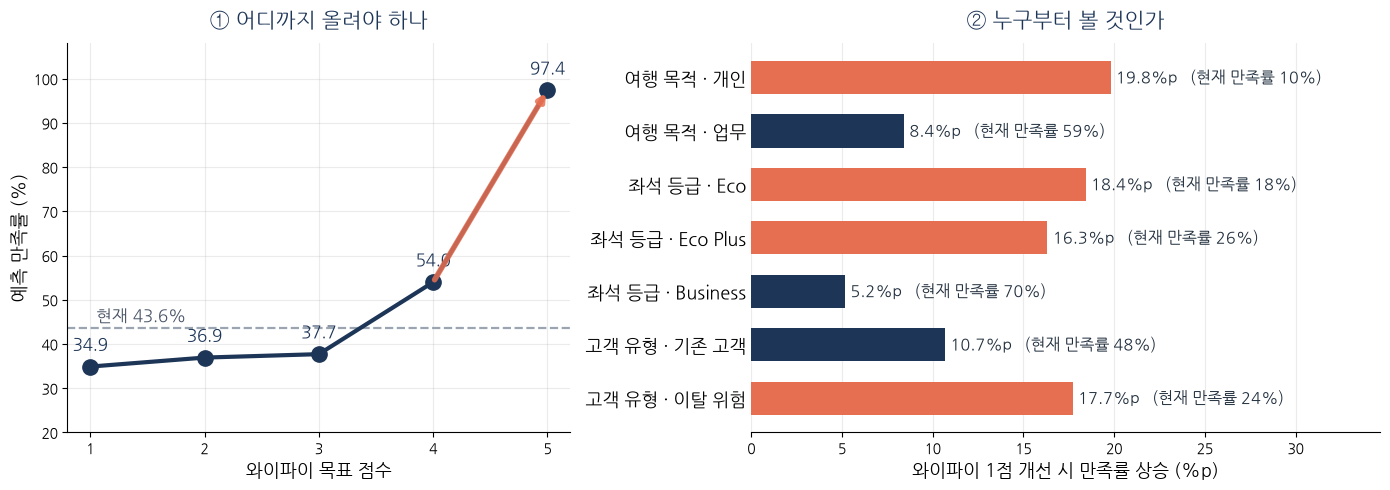

In [137]:
# ============================================================
#  "와이파이를 어디까지 올릴지 · 어떤 승객부터 볼지"에 답하는 분석
#  ─ 우선순위 매트릭스(슬라이드 10)의 다음 질문을 데이터로 닫는다 ─
#
#  선행 조건 : 노트북 셀 31까지 실행되어 아래 세 이름이 살아 있어야 한다.
#      m_base    … LGBMClassifier (X_train[base_cols]로 학습)
#      Xb        … X_test[base_cols]
#      base_cols … 피처 컬럼 리스트
# ============================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

for _n in ('m_base', 'Xb', 'base_cols'):
    assert _n in dir(), f'{_n} 이(가) 없습니다. 셀 31까지 먼저 실행하세요.'

WIFI  = 'Inflight_wifi_service'
MAIN, TEAL, ORANGE, GRAY = '#1D3557', '#2A9D8F', '#E76F51', '#9AA5B1'

base_rate = m_base.predict_proba(Xb)[:, 1].mean()
used      = Xb[WIFI] >= 1                      # 0점(미이용) 승객은 항상 제외
print(f'현재 예측 만족률 {base_rate:.4f} · 와이파이 이용 승객 {used.mean():.1%}')


# ── ① 어디까지 올려야 하나 : 목표 점수 곡선 ───────────────────
#     이용 승객 전원을 k점으로 "고정"했을 때 예측 만족률
rows = []
for k in range(1, 6):
    Xc = Xb.copy(); Xc.loc[used, WIFI] = k
    r  = m_base.predict_proba(Xc)[:, 1].mean()
    rows.append({'목표점수': k, '예측_만족률_%': r * 100,
                 '현재대비_%p': (r - base_rate) * 100})
curve = pd.DataFrame(rows).set_index('목표점수')
curve['직전구간_대비_%p'] = curve['예측_만족률_%'].diff()
print('\n■ ① 목표 점수 곡선 (이용 승객 전원을 k점으로 고정)')
display(curve.round(2))

jump = curve['직전구간_대비_%p'].idxmax()
print(f'   → 가장 가파른 구간 : {jump-1}점 → {jump}점 '
      f'({curve.loc[jump, "직전구간_대비_%p"]:.2f}%p)')


# ── ② 얼마나 들여야 하나 : 미달 승객만 목표까지 ───────────────
rows = []
for goal in range(2, 6):
    Xc = Xb.copy()
    m  = used & (Xb[WIFI] < goal)              # 이미 목표 이상인 승객은 건드리지 않음
    Xc.loc[m, WIFI] = goal
    r = m_base.predict_proba(Xc)[:, 1].mean()
    rows.append({'목표점수': goal, '대상승객_비율_%': m.mean() * 100,
                 '현재대비_%p': (r - base_rate) * 100})
scen = pd.DataFrame(rows).set_index('목표점수')
scen['대상_1%p당_효과'] = scen['현재대비_%p'] / scen['대상승객_비율_%']
print('\n■ ② 목표 미달 승객만 끌어올리는 시나리오')
display(scen.round(3))


# ── ③ 누구부터 볼 것인가 : 세그먼트별 1점 개선 효과 ────────────
SEGS = {
    '여행 목적': {'개인': Xb['Type_of_Travel'] == 0, '업무': Xb['Type_of_Travel'] == 1},
    '좌석 등급': {'Eco': Xb['Class'] == 0, 'Eco Plus': Xb['Class'] == 1,
                  'Business': Xb['Class'] == 2},
    '고객 유형': {'기존 고객': Xb['Customer_Type'] == 0, '이탈 위험': Xb['Customer_Type'] == 1},
}
rows = []
for gname, groups in SEGS.items():
    for sname, mask in groups.items():
        Xs = Xb[mask.values]
        b  = m_base.predict_proba(Xs)[:, 1].mean()
        Xc = Xs.copy(); u = Xc[WIFI] >= 1
        Xc.loc[u, WIFI] = np.minimum(Xc.loc[u, WIFI] + 1, 5)
        rows.append({'구분': gname, '세그먼트': sname, '승객수': len(Xs),
                     '현재_평균평점': Xs.loc[u, WIFI].mean(),
                     '현재_만족률_%': b * 100,
                     '1점개선_%p': (m_base.predict_proba(Xc)[:, 1].mean() - b) * 100})
seg = pd.DataFrame(rows)
print('\n■ ③ 세그먼트별 와이파이 1점 개선 효과')
display(seg.round(3).style.hide(axis='index')
           .background_gradient(subset=['1점개선_%p'], cmap='Oranges'))


# ── ④ 그래프 2장 ─────────────────────────────────────────────
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={'width_ratios': [1, 1.25]})

# ④-1 목표 점수 곡선
a1.plot(curve.index, curve['예측_만족률_%'], marker='o', ms=11, lw=3, color=MAIN, zorder=3)
a1.axhline(base_rate * 100, ls='--', lw=1.6, color=GRAY)
a1.text(1.05, base_rate * 100 + 1.5, f'현재 {base_rate*100:.1f}%', fontsize=12, color='#4A5568')
for k, v in curve['예측_만족률_%'].items():
    a1.annotate(f'{v:.1f}', (k, v), xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=12, color=MAIN, fontweight='bold')
a1.annotate('', xy=(jump, curve.loc[jump, '예측_만족률_%']),
            xytext=(jump - 1, curve.loc[jump - 1, '예측_만족률_%']),
            arrowprops=dict(arrowstyle='-|>', lw=4, color=ORANGE, alpha=.85))
a1.set_xticks(range(1, 6)); a1.set_xlabel('와이파이 목표 점수', fontsize=13)
a1.set_ylabel('예측 만족률 (%)', fontsize=13)
a1.set_title('① 어디까지 올려야 하나', fontsize=15, color=MAIN, fontweight='bold', pad=12)
a1.set_ylim(20, 108); a1.grid(alpha=.25); a1.set_axisbelow(True)
for s in ('top', 'right'): a1.spines[s].set_visible(False)

# ④-2 세그먼트별 효과
lab = seg['구분'] + ' · ' + seg['세그먼트']
yp  = np.arange(len(seg))[::-1]
mx  = seg['1점개선_%p'].max()
col = [ORANGE if v > mx * 0.8 else MAIN for v in seg['1점개선_%p']]
a2.barh(yp, seg['1점개선_%p'], height=0.62, color=col)
for y_, v, r in zip(yp, seg['1점개선_%p'], seg['현재_만족률_%']):
    a2.text(v + 0.3, y_, f'{v:.1f}%p   (현재 만족률 {r:.0f}%)', va='center',
            fontsize=11.5, color='#22303F')
a2.set_yticks(yp); a2.set_yticklabels(lab, fontsize=13); a2.tick_params(axis='y', length=0)
a2.set_xlim(0, mx * 1.75)
a2.set_xlabel('와이파이 1점 개선 시 만족률 상승 (%p)', fontsize=13)
a2.set_title('② 누구부터 볼 것인가', fontsize=15, color=MAIN, fontweight='bold', pad=12)
a2.grid(axis='x', alpha=.25); a2.set_axisbelow(True)
for s in ('top', 'right', 'left'): a2.spines[s].set_visible(False)

plt.tight_layout(); plt.show()